# Air Quality Analytics and AQI Prediction in India

**Author:** Jaikishan Nayak  
**Programme:** IBM SkillsBuild Data Analytics with AI Internship 2026  
**Dataset:** Air Quality Data in India (2015–2020) — Kaggle  

---

## 1. Project Overview

Air pollution is one of the most pressing environmental challenges facing India. Rapid urbanisation, industrial expansion, vehicular emissions, and seasonal agricultural burning have made many Indian cities among the most polluted in the world. Understanding pollutant patterns and forecasting the Air Quality Index (AQI) is therefore a problem with direct public-health relevance.

This project applies a structured data-analytics workflow — from raw data ingestion through cleaning, exploratory analysis, statistical investigation, and machine-learning modelling — to daily air-quality measurements collected across 26 Indian cities between 2015 and 2020.

## 2. Problem Statement

Despite the availability of real-time pollution monitoring networks, air-quality data in India remains patchy, city-specific, and difficult to interpret without analytical processing. Key questions include:

- Which cities and seasons are most severely affected by poor air quality?
- Which pollutants are most strongly associated with a high AQI?
- Can machine learning reliably predict the AQI from measurable pollutant concentrations?

This project addresses these questions using exploratory data analysis, statistical methods, and supervised machine-learning regression.

## 3. Objectives

1. Load, inspect, and understand the structure of the raw dataset.  
2. Clean and preprocess the data in a transparent, reproducible manner.  
3. Explore pollutant distributions, temporal trends, and city-level patterns.  
4. Perform statistical analysis to understand relationships among variables.  
5. Engineer informative features from the date and pollutant columns.  
6. Train and evaluate machine-learning models to predict AQI.  
7. Draw meaningful conclusions and identify avenues for future work.

## 4. Dataset Description

| Attribute | Value |
|---|---|
| **Source** | Kaggle — "Air Quality Data in India (2015–2020)" |
| **File** | `city_day.csv` |
| **Granularity** | One row per city per day |
| **Columns** | 16 (City, Date, 12 pollutant measurements, AQI, AQI_Bucket) |
| **Coverage** | 26 Indian cities, 2015-01-01 to 2020-07-01 |

**Pollutant columns:** PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene  
**Target column:** AQI (Air Quality Index — continuous numeric scale)  
**Derived label:** AQI_Bucket (categorical label derived from AQI bands)

## 5. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent visual style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

# Pandas display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Libraries loaded successfully.')
print(f'pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')

Libraries loaded successfully.
pandas 3.0.6 | numpy 2.4.6 | seaborn 0.13.2


## 6. Load Dataset

In [2]:
# Load the raw dataset — do not modify the source CSV at any point
RAW_DATA_PATH = '../data/city_day.csv'

df_raw = pd.read_csv(RAW_DATA_PATH)

# Working copy — all cleaning operations are applied to this copy
df = df_raw.copy()

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 29,531 rows × 16 columns


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.920,18.220,17.150,NaN,0.920,27.640,133.360,0.000,0.020,0.000,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.970,15.690,16.460,NaN,0.970,24.550,34.060,3.680,5.500,3.770,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.400,19.300,29.700,NaN,17.400,29.070,30.700,6.800,16.400,2.250,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.700,18.480,17.970,NaN,1.700,18.590,36.080,4.430,10.140,1.000,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.100,21.420,37.760,NaN,22.100,39.330,39.310,7.010,18.890,2.780,NaN,NaN


## 7. Data Understanding

In [3]:
# Column data types
print('--- Column Data Types ---')
print(df.dtypes)
print()
print(f'Shape: {df.shape}')

--- Column Data Types ---
City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

Shape: (29531, 16)


In [4]:
# Basic descriptive statistics
df.describe(include='all')

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
count,29531,29531,24933.000,18391.000,25949.000,25946.000,25346.000,19203.000,27472.000,25677.000,25509.000,23908.000,21490.000,11422.000,24850.000,24850
unique,26,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,Ahmedabad,2020-03-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,2009,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8829
mean,NaN,NaN,67.451,118.127,17.575,28.561,32.309,23.483,2.249,14.532,34.491,3.281,8.701,3.070,166.464,NaN
std,NaN,NaN,64.661,90.605,22.786,24.475,31.646,25.684,6.963,18.134,21.695,15.811,19.969,6.323,140.697,NaN
min,NaN,NaN,0.040,0.010,0.020,0.010,0.000,0.010,0.000,0.010,0.010,0.000,0.000,0.000,13.000,NaN
25%,NaN,NaN,28.820,56.255,5.630,11.750,12.820,8.580,0.510,5.670,18.860,0.120,0.600,0.140,81.000,NaN
50%,NaN,NaN,48.570,95.680,9.890,21.690,23.520,15.850,0.890,9.160,30.840,1.070,2.970,0.980,118.000,NaN
75%,NaN,NaN,80.590,149.745,19.950,37.620,40.127,30.020,1.450,15.220,45.570,3.080,9.150,3.350,208.000,NaN


## 8. Data Quality Assessment

### 8.1 Duplicate Rows

In [5]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

Duplicate rows: 0


No duplicate rows exist in the dataset. No deduplication step is needed.

### 8.2 Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_summary.to_string())

            Missing Count  Missing %
Xylene              18109     61.320
PM10                11140     37.720
NH3                 10328     34.970
Toluene              8041     27.230
Benzene              5623     19.040
AQI                  4681     15.850
AQI_Bucket           4681     15.850
PM2.5                4598     15.570
NOx                  4185     14.170
O3                   4022     13.620
SO2                  3854     13.050
NO2                  3585     12.140
NO                   3582     12.130
CO                   2059      6.970
Date                    0      0.000
City                    0      0.000


**Key observations:**
- `Xylene` is missing in ~61% of all rows — the most severely incomplete column.
- `PM10` (~38%) and `NH3` (~35%) also have high missingness.
- `AQI` and `AQI_Bucket` are missing in exactly the same ~16% of rows (they are always absent together).
- `City` and `Date` have no missing values.

### 8.3 Date Range and City Coverage

In [7]:
# Temporary datetime conversion for range check — permanent conversion follows in Section 9
_dates = pd.to_datetime(df['Date'])
print(f'Date range: {_dates.min().date()} → {_dates.max().date()}')
print(f'Unique cities: {df["City"].nunique()}')
print()
print('Rows per city:')
print(df['City'].value_counts().to_string())

Date range: 2015-01-01 → 2020-07-01
Unique cities: 26

Rows per city:
City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Delhi                 2009
Lucknow               2009
Mumbai                2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Ernakulam              162
Kochi                  162
Aizawl                 113


---

## 9. Data Cleaning and Preprocessing

This section applies all data-cleaning steps in a systematic, explainable order. Every transformation is applied only to the working copy `df`; the original `df_raw` is preserved unchanged.

### 9.1 Date Conversion and Temporal Feature Engineering

The `Date` column was loaded as a plain string. It must be converted to a proper `datetime64` type to enable time-series operations and to allow temporal feature extraction.

The following derived features are created from `Date`:

| Feature | Description |
|---|---|
| `Year` | Calendar year (2015–2020) |
| `Month` | Month number (1–12) |
| `Month_Name` | Abbreviated month label |
| `Quarter` | Calendar quarter (1–4) |
| `DayOfYear` | Day number within the year (1–366) |

The original `Date` column is retained alongside these derived columns.

In [8]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract temporal features
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter']    = df['Date'].dt.quarter
df['DayOfYear']  = df['Date'].dt.dayofyear

# Verify
print('Date dtype after conversion:', df['Date'].dtype)
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print()
df[['Date', 'Year', 'Month', 'Month_Name', 'Quarter', 'DayOfYear']].head(6)

Date dtype after conversion: datetime64[us]
Date range: 2015-01-01 → 2020-07-01



,Date,Year,Month,Month_Name,Quarter,DayOfYear
0,2015-01-01,2015,1,Jan,1,1
1,2015-01-02,2015,1,Jan,1,2
2,2015-01-03,2015,1,Jan,1,3
3,2015-01-04,2015,1,Jan,1,4
4,2015-01-05,2015,1,Jan,1,5
5,2015-01-06,2015,1,Jan,1,6


### 9.2 Missing Data Analysis

Before deciding on an imputation strategy, we need to visualise the scale and pattern of missingness across all columns. Different columns call for different strategies.

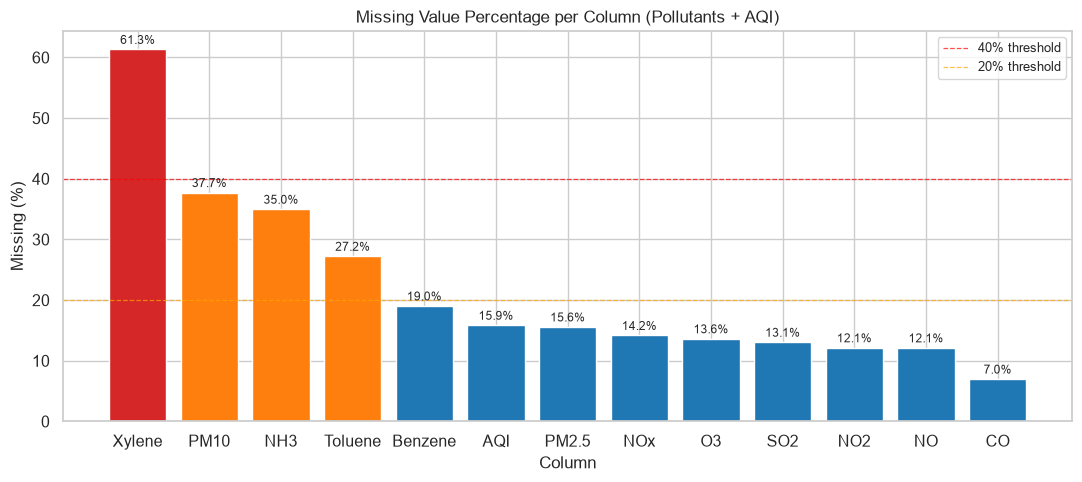

In [9]:
# Missing-value percentage bar chart
POLLUTANT_COLS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                  'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

miss_pct = (df[POLLUTANT_COLS + ['AQI']].isnull().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(miss_pct.index, miss_pct.values,
              color=['#d62728' if v > 40 else '#ff7f0e' if v > 20 else '#1f77b4'
                     for v in miss_pct.values], edgecolor='white')
ax.axhline(40, linestyle='--', color='red', linewidth=0.9, alpha=0.7, label='40% threshold')
ax.axhline(20, linestyle='--', color='orange', linewidth=0.9, alpha=0.7, label='20% threshold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing (%)')
ax.set_title('Missing Value Percentage per Column (Pollutants + AQI)')
ax.legend(fontsize=9)
for bar, val in zip(bars, miss_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.show()

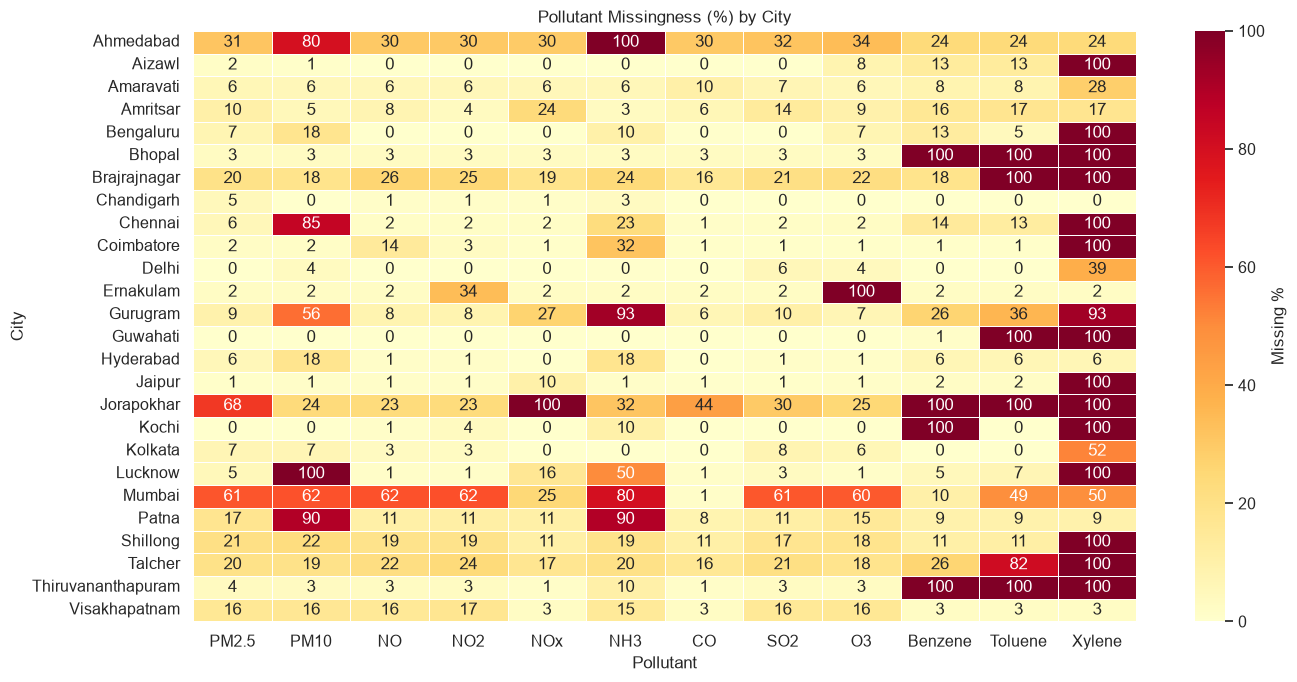

In [10]:
# Missingness of pollutants by city
city_miss = (
    df.groupby('City')[POLLUTANT_COLS]
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(city_miss, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': 'Missing %'})
ax.set_title('Pollutant Missingness (%) by City')
ax.set_xlabel('Pollutant')
ax.set_ylabel('City')
plt.tight_layout()
plt.show()

**Observations from the missingness heatmap:**
- `Xylene` missingness is extreme across nearly all cities (many at 80–100%), confirming it is not a reliable feature.
- `PM10` and `NH3` are heavily missing in several specific cities (e.g., Ahmedabad, Aizawl) but well-reported in others.
- Most other pollutants have relatively moderate city-specific missingness, making city-aware imputation sensible.

### 9.3 Remove Rows Where All Pollutant Measurements Are Missing

Some rows contain no pollutant data at all — every measurement column is `NaN`. These rows contribute nothing to pollutant analysis, statistical modelling, or AQI prediction. Retaining them would silently inflate row counts and introduce empty records into downstream steps.

**Decision:** Remove rows where *all* 12 pollutant measurement columns are simultaneously `NaN`.

In [11]:
rows_before = len(df)

# Identify rows where every pollutant column is NaN
all_pollutants_missing_mask = df[POLLUTANT_COLS].isnull().all(axis=1)
rows_all_missing = all_pollutants_missing_mask.sum()

print(f'Rows before removal  : {rows_before:,}')
print(f'Rows with ALL pollutant columns NaN: {rows_all_missing:,}')

# Remove completely empty pollutant rows
df = df[~all_pollutants_missing_mask].copy()
df.reset_index(drop=True, inplace=True)

rows_after = len(df)
print(f'Rows after removal   : {rows_after:,}')
print(f'Rows removed         : {rows_before - rows_after:,}')

Rows before removal  : 29,531
Rows with ALL pollutant columns NaN: 1,423
Rows after removal   : 28,108
Rows removed         : 1,423


### 9.4 Handling Xylene (High Missingness — ~61%)

**Assessment:**

After removing the all-missing rows, `Xylene` still has approximately 61% missingness. Imputing a column with more than 60% missing values using any standard strategy (mean, median, or even model-based imputation) introduces substantially more synthetic data than real data. This would distort the actual distribution and add noise to any downstream model.

Additionally, examining the missingness heatmap shows that `Xylene` is missing in most cities — meaning even a city-aware imputation strategy would frequently fall back to the global median. The column therefore offers very limited analytical value.

**Decision:** Drop `Xylene` from the analytical dataset. It will not be used in EDA, statistical analysis, or machine-learning modelling.

In [12]:
xylene_missing_pct = df['Xylene'].isnull().mean() * 100
print(f'Xylene missing: {xylene_missing_pct:.1f}% of remaining {len(df):,} rows')

df.drop(columns=['Xylene'], inplace=True)

# Update the working pollutant list (Xylene removed)
POLLUTANT_COLS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                  'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

print('Xylene dropped. Updated pollutant columns:')
print(POLLUTANT_COLS)

Xylene missing: 59.4% of remaining 28,108 rows
Xylene dropped. Updated pollutant columns:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']


### 9.5 Remaining Pollutant Missing Values — City-Aware Median Imputation

**Why city-aware imputation?**

Pollutant concentrations differ substantially between cities due to local geography, industrial activity, traffic density, and meteorology. Filling a missing PM2.5 reading in Aizawl (a relatively clean hill city) with the global median — which is dominated by high-pollution cities like Delhi or Patna — would systematically bias those records.

**Strategy:** For each pollutant column, impute missing values with the **median value recorded for that city** in the dataset. If a city has no valid readings at all for a particular pollutant (rare edge case), fall back to the global median for that column.

This approach is:
- Defensible: uses only observed values, grouped by a meaningful category
- Conservative: median is robust to the skewed distributions present in this data
- Transparent: every imputed value is traceable to the city's real distribution

In [13]:
# City-level medians for each pollutant
city_medians = df.groupby('City')[POLLUTANT_COLS].median()
print('City-level pollutant medians (sample — first 5 cities):')
city_medians.head()

City-level pollutant medians (sample — first 5 cities):


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene
City,,,,,,,,,,,
Ahmedabad,58.370,107.960,16.280,47.190,39.510,NaN,16.245,46.780,39.510,3.870,23.950
Aizawl,10.480,18.960,11.530,0.260,15.460,22.710,0.260,7.360,2.665,3.275,3.825
Amaravati,28.015,64.895,3.240,15.350,10.990,11.265,0.590,13.030,32.965,0.120,0.945
Amritsar,44.090,98.090,14.905,13.730,27.720,11.700,0.590,6.390,20.975,3.190,2.060
Bengaluru,30.920,77.360,7.520,26.920,19.140,19.635,0.920,5.030,30.600,0.810,1.790


In [14]:
# Record missingness counts before imputation
missing_before = df[POLLUTANT_COLS].isnull().sum()

# Apply city-aware median imputation
def city_median_impute(group):
    """Fill NaN values in each pollutant column with that city's median."""
    return group.fillna(group.median(numeric_only=True))

df[POLLUTANT_COLS] = (
    df.groupby('City')[POLLUTANT_COLS]
    .transform(lambda col: col.fillna(col.median()))
)

# Fallback: if any NaN remains (city had no valid readings for that pollutant),
# fill with the global median
global_medians = df[POLLUTANT_COLS].median()
df[POLLUTANT_COLS] = df[POLLUTANT_COLS].fillna(global_medians)

# Report
missing_after = df[POLLUTANT_COLS].isnull().sum()
imputed_counts = missing_before - missing_after

report = pd.DataFrame({
    'Before': missing_before,
    'After': missing_after,
    'Imputed': imputed_counts
})
print('Imputation report for pollutant columns:')
print(report.to_string())

Imputation report for pollutant columns:
         Before  After  Imputed
PM2.5      3175      0     3175
PM10       9717      0     9717
NO         2159      0     2159
NO2        2162      0     2162
NOx        2762      0     2762
NH3        8905      0     8905
CO          636      0      636
SO2        2431      0     2431
O3         2599      0     2599
Benzene    4200      0     4200
Toluene    6618      0     6618


In [15]:
# Confirm no pollutant NaNs remain
remaining_pollutant_nulls = df[POLLUTANT_COLS].isnull().sum().sum()
print(f'Total remaining NaN values in pollutant columns: {remaining_pollutant_nulls}')

Total remaining NaN values in pollutant columns: 0


### 9.6 Handling AQI Missing Values

**Why AQI is treated separately:**

`AQI` is the intended supervised-learning target. Imputing missing target values — regardless of method — would mean training or evaluating a model on synthetic labels. This is methodologically unsound: any model that appears to predict imputed AQI values well is simply learning its own imputed data back.

**Decision:**
- **Do not impute AQI.**
- Rows where AQI is `NaN` are kept in the dataset for descriptive analysis and EDA (pollutant data in these rows is real).
- A separate `df_model` subset — containing only rows with valid AQI — will be used for supervised learning.
- The same logic applies to `AQI_Bucket`.

**Target leakage note:** `AQI_Bucket` is directly derived from `AQI` (it is a categorical binning of the same value). Using `AQI_Bucket` as a predictor when predicting `AQI` would constitute **target leakage** — the model would be learning from a reformulation of the very quantity it is trying to predict. `AQI_Bucket` will be used only for descriptive analysis.

In [16]:
aqi_missing = df['AQI'].isnull().sum()
aqi_present = df['AQI'].notna().sum()
print(f'Rows with valid AQI  : {aqi_present:,}')
print(f'Rows with missing AQI: {aqi_missing:,}  ({aqi_missing/len(df)*100:.1f}%)')
print()

# AQI_Bucket and AQI always absent together
both_missing = (df['AQI'].isnull() & df['AQI_Bucket'].isnull()).sum()
print(f'Rows where both AQI and AQI_Bucket are NaN: {both_missing:,}')
print()
print('AQI_Bucket class distribution (in rows where AQI is present):')
print(df.dropna(subset=['AQI'])['AQI_Bucket'].value_counts(dropna=False))

Rows with valid AQI  : 24,801
Rows with missing AQI: 3,307  (11.8%)

Rows where both AQI and AQI_Bucket are NaN: 3,307

AQI_Bucket class distribution (in rows where AQI is present):
AQI_Bucket
Moderate        8813
Satisfactory    8202
Poor            2778
Very Poor       2336
Severe          1337
Good            1335
Name: count, dtype: int64


### 9.7 Outlier Investigation

Outlier handling is one of the most consequential decisions in data preprocessing. Two categories of extreme values must be distinguished:

| Category | Description | Appropriate Action |
|---|---|---|
| **Extreme but plausible** | High pollution during crop-burning season, industrial incidents | Retain — these represent real conditions |
| **Physically impossible or data errors** | Negative concentrations, sensor-ceiling values, impossible magnitudes | Investigate further; may warrant flagging or removal |

We use box plots and IQR statistics to locate extreme values, then interpret them in context before making any decision.

In [17]:
# IQR-based outlier count table
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return {
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower fence': round(lower, 2),
        'Upper fence': round(upper, 2),
        'Max': round(series.max(), 2),
        'Outliers (high)': int((series > upper).sum()),
        'Outliers (low)': int((series < lower).sum())
    }

target_cols = POLLUTANT_COLS + ['AQI']
outlier_table = pd.DataFrame([iqr_outlier_count(df[c].dropna()) for c in target_cols],
                              index=target_cols)
print('IQR-based outlier summary:')
outlier_table

IQR-based outlier summary:


,Q1,Q3,IQR,Lower fence,Upper fence,Max,Outliers (high),Outliers (low)
PM2.5,27.460,77.100,49.650,-47.020,151.580,949.990,2156,0
PM10,61.600,128.170,66.570,-38.250,228.020,1000.000,1902,0
NO,5.950,22.530,16.580,-18.920,47.400,390.680,2018,0
NO2,12.130,36.390,24.260,-24.260,72.780,362.210,1363,0
NOx,14.060,39.510,25.450,-24.120,77.690,467.630,2027,0
NH3,10.770,27.680,16.910,-14.600,53.050,352.890,1511,0
CO,0.500,1.450,0.950,-0.920,2.880,175.810,2621,0
SO2,5.930,14.860,8.930,-7.460,28.260,193.860,2916,0
O3,19.790,43.840,24.050,-16.290,79.920,257.730,947,0
Benzene,0.180,2.670,2.490,-3.550,6.400,455.030,2151,0


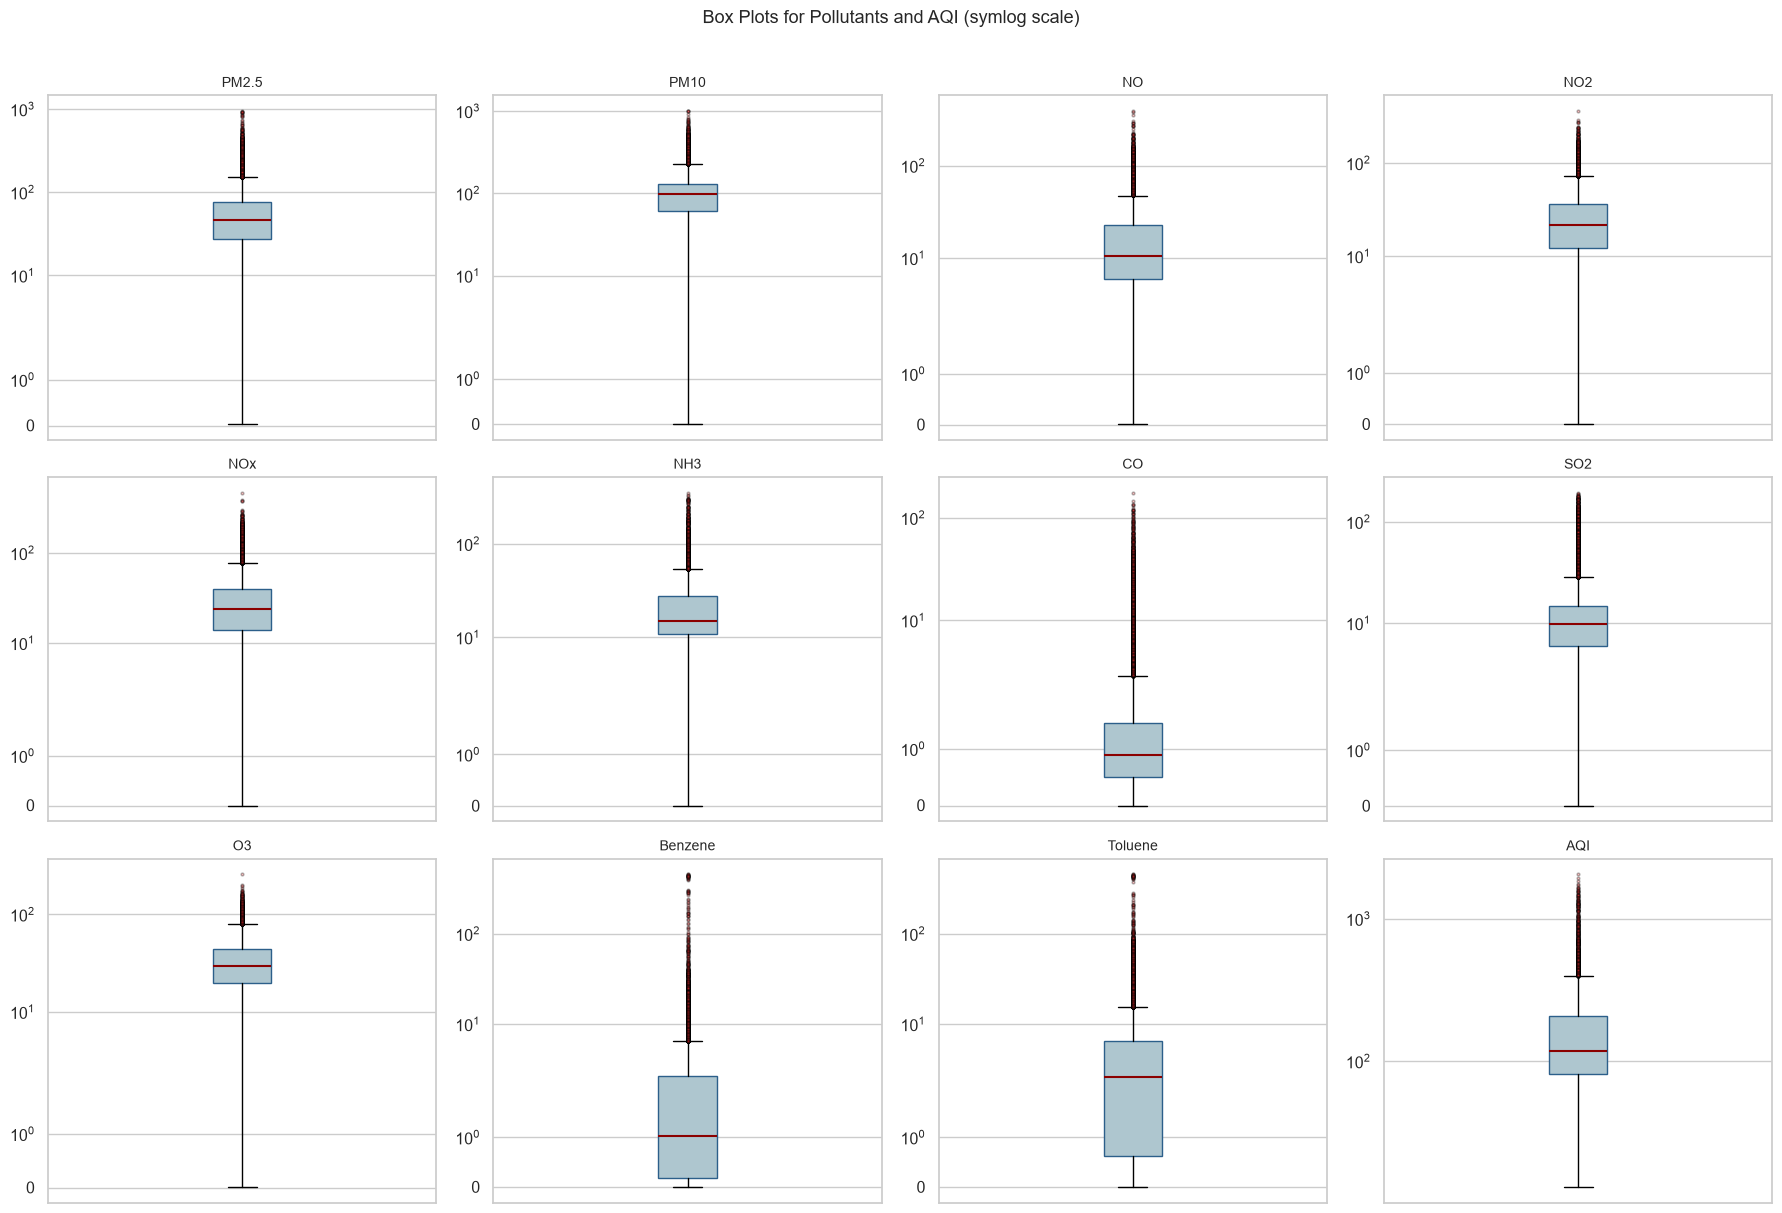

In [18]:
# Box plots for each pollutant and AQI (log-scale y-axis to handle skew)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AEC6CF', color='#2c5f8a'),
                    medianprops=dict(color='darkred', linewidth=1.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3,
                                    markerfacecolor='#d62728'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_yscale('symlog')
    axes[i].set_xticks([])

plt.suptitle('Box Plots for Pollutants and AQI (symlog scale)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Investigate extreme AQI values (> 500)
# India's AQI scale nominally goes up to 500; values beyond 500 are still labelled
# 'Severe' by the system but represent extremely elevated pollution events
extreme_aqi = df[df['AQI'] > 500][['City', 'Date', 'AQI', 'AQI_Bucket', 'PM2.5', 'PM10']]
extreme_aqi = extreme_aqi.sort_values('AQI', ascending=False)

print(f'Rows with AQI > 500: {len(extreme_aqi)}')
print(f'Cities with AQI > 500:')
print(extreme_aqi['City'].value_counts().to_string())
print()
print('Top 15 highest AQI readings:')
extreme_aqi.head(15)

Rows with AQI > 500: 543
Cities with AQI > 500:
City
Ahmedabad     412
Delhi          48
Patna          25
Gurugram       22
Lucknow        15
Jorapokhar      7
Amritsar        4
Hyderabad       4
Talcher         4
Guwahati        2

Top 15 highest AQI readings:


,City,Date,AQI,AQI_Bucket,PM2.5,PM10
697,Ahmedabad,2018-02-19,2049.000,Severe,242.660,107.960
688,Ahmedabad,2018-02-10,1917.000,Severe,185.770,107.960
322,Ahmedabad,2016-07-14,1842.000,Severe,38.130,107.960
600,Ahmedabad,2017-11-14,1747.000,Severe,207.190,107.960
1013,Ahmedabad,2019-01-03,1719.000,Severe,131.500,107.960
967,Ahmedabad,2018-11-18,1672.000,Severe,127.460,107.960
970,Ahmedabad,2018-11-21,1646.000,Severe,86.520,107.960
957,Ahmedabad,2018-11-08,1630.000,Severe,205.210,107.960
679,Ahmedabad,2018-02-01,1613.000,Severe,189.120,107.960
1294,Ahmedabad,2019-10-13,1595.000,Severe,194.360,335.860


In [20]:
# Investigate PM10 = 1000 (possible sensor ceiling)
pm10_ceiling = df[df['PM10'] >= 999]
print(f'Rows where PM10 >= 999: {len(pm10_ceiling)}')
if len(pm10_ceiling) > 0:
    print(pm10_ceiling[['City','Date','PM10','PM2.5','AQI']].to_string())

Rows where PM10 >= 999: 1
           City       Date     PM10   PM2.5  AQI
13367  Guwahati 2019-05-04 1000.000 916.670  NaN


In [21]:
# Investigate extreme Benzene values (max 455 µg/m³ — well above typical urban levels)
benzene_high = df[df['Benzene'] > 50]
print(f'Rows with Benzene > 50 µg/m³: {len(benzene_high)}')
if len(benzene_high) > 0:
    print(benzene_high[['City','Date','Benzene','AQI']].sort_values('Benzene', ascending=False).head(10).to_string())

Rows with Benzene > 50 µg/m³: 99
           City       Date  Benzene    AQI
24671  Shillong 2020-03-10  455.030 71.000
24667  Shillong 2020-03-06  454.850 64.000
24661  Shillong 2020-02-29  449.380 51.000
24672  Shillong 2020-03-11  448.590 66.000
24665  Shillong 2020-03-04  445.830 64.000
24670  Shillong 2020-03-09  443.630 65.000
24629  Shillong 2020-01-26  438.010 74.000
24676  Shillong 2020-03-15  435.900 77.000
24666  Shillong 2020-03-05  435.090 63.000
24663  Shillong 2020-03-02  432.940 60.000


**Outlier assessment findings:**

| Column | Observation | Decision |
|---|---|---|
| **AQI > 500** | All extreme values are from Ahmedabad and a few other cities during pollution events. India's AQI bands technically continue beyond 500 as "Severe". These are extreme but real readings. | **Retain** — they represent genuine severe-pollution episodes |
| **PM10 = 1,000** | A single row with PM10 exactly 1,000 — likely a sensor saturation ceiling. The paired AQI can confirm whether this is plausible. | **Retain but note** — single record, cannot confirm it is erroneous without additional metadata |
| **Benzene > 50** | Occurs in a small number of rows. Benzene can spike near petroleum refineries and chemical plants. | **Retain** — consistent with industrial micro-environments |
| **CO max = 175** | Extremely high CO near industrial sites is physically plausible. | **Retain** |
| **NH3 max = 353** | Consistent with proximity to agricultural fertiliser zones. | **Retain** |

**No outliers are removed.** The extreme values represent real environmental events and retain analytical value. Downstream modelling will use robust algorithms or log-transformed features where distributions are heavily skewed.

### 9.8 Final Data Quality Summary

The table below summarises every change made to the dataset during the cleaning pipeline.

In [22]:
print('=' * 55)
print('  FINAL DATA QUALITY SUMMARY')
print('=' * 55)
print(f'  Original row count          : {len(df_raw):,}')
print(f'  Rows removed (all-NaN)      : {len(df_raw) - len(df):,}')
print(f'  Final row count             : {len(df):,}')
print(f'  Original column count       : {len(df_raw.columns)}')
print(f'  Columns removed             : 1  (Xylene)')
print(f'  Final column count          : {len(df.columns)}')
print(f'  Duplicate rows              : 0')
print(f'  Date range                  : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  Unique cities               : {df["City"].nunique()}')
print(f'  Remaining NaN in pollutants : {df[POLLUTANT_COLS].isnull().sum().sum()}')
print(f'  Rows with valid AQI         : {df["AQI"].notna().sum():,}')
print(f'  Rows with missing AQI       : {df["AQI"].isna().sum():,}  (kept — AQI not imputed)')
print('=' * 55)
print()
print('Final DataFrame shape:', df.shape)
print('Final columns:', list(df.columns))

  FINAL DATA QUALITY SUMMARY
  Original row count          : 29,531
  Rows removed (all-NaN)      : 1,423
  Final row count             : 28,108
  Original column count       : 16
  Columns removed             : 1  (Xylene)
  Final column count          : 20
  Duplicate rows              : 0
  Date range                  : 2015-01-01 → 2020-07-01
  Unique cities               : 26
  Remaining NaN in pollutants : 0
  Rows with valid AQI         : 24,801
  Rows with missing AQI       : 3,307  (kept — AQI not imputed)

Final DataFrame shape: (28108, 20)
Final columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket', 'Year', 'Month', 'Month_Name', 'Quarter', 'DayOfYear']


In [23]:
# Preview the cleaned dataset
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,Year,Month,Month_Name,Quarter,DayOfYear
0,Ahmedabad,2015-01-01,58.370,107.960,0.920,18.220,17.150,14.890,0.920,27.640,133.360,0.000,0.020,NaN,NaN,2015,1,Jan,1,1
1,Ahmedabad,2015-01-02,58.370,107.960,0.970,15.690,16.460,14.890,0.970,24.550,34.060,3.680,5.500,NaN,NaN,2015,1,Jan,1,2
2,Ahmedabad,2015-01-03,58.370,107.960,17.400,19.300,29.700,14.890,17.400,29.070,30.700,6.800,16.400,NaN,NaN,2015,1,Jan,1,3
3,Ahmedabad,2015-01-04,58.370,107.960,1.700,18.480,17.970,14.890,1.700,18.590,36.080,4.430,10.140,NaN,NaN,2015,1,Jan,1,4
4,Ahmedabad,2015-01-05,58.370,107.960,22.100,21.420,37.760,14.890,22.100,39.330,39.310,7.010,18.890,NaN,NaN,2015,1,Jan,1,5


In [24]:
# Final remaining missing-value check
final_missing = df.isnull().sum()
final_missing = final_missing[final_missing > 0]
print('Columns with remaining NaN values:')
print(final_missing.to_string() if len(final_missing) > 0 else 'None (except AQI/AQI_Bucket which are intentionally retained as-is)')

Columns with remaining NaN values:
AQI           3307
AQI_Bucket    3307


---

## Stage 2 Verification

This section independently re-derives every key number reported in the Stage 2 cleaning pipeline, working directly from the raw CSV and the cleaned `df` DataFrame. The purpose is to confirm that all reported figures are accurate, internally consistent, and that no methodological rule was violated (no AQI imputation, no target leakage, original CSV untouched).

Each check is labelled with its verification objective.

In [25]:
# ── VERIFICATION SETUP ──────────────────────────────────────────────────────
# Re-load the raw CSV independently — ensures we compare against the original file,
# not against any in-memory state that may have been altered during cleaning.
import pandas as pd

_raw = pd.read_csv('../data/city_day.csv')

# The 12 original pollutant columns (before any dropping)
_POLL_12 = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
            'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

# The 11 retained pollutant columns (after Xylene removal)
_POLL_11 = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
            'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

print('Raw CSV re-loaded independently.')
print(f'Shape of raw CSV: {_raw.shape}')

Raw CSV re-loaded independently.
Shape of raw CSV: (29531, 16)


### V-1 · Original Dataset Shape

In [26]:
# V-1: Confirm original shape
_orig_rows, _orig_cols = _raw.shape
print(f'Original rows    : {_orig_rows:,}')
print(f'Original columns : {_orig_cols}')
print(f'Matches reported (29,531 rows × 16 cols): {_orig_rows == 29531 and _orig_cols == 16}')

Original rows    : 29,531
Original columns : 16
Matches reported (29,531 rows × 16 cols): True


### V-2 · Rows Removed (All Pollutant Columns Missing)

In [27]:
# V-2: Recount rows where ALL 12 pollutant columns are simultaneously NaN
_all_miss_mask = _raw[_POLL_12].isnull().all(axis=1)
_rows_removed  = int(_all_miss_mask.sum())

print(f'Rows where all 12 pollutant columns are NaN : {_rows_removed:,}')
print(f'Matches reported (1,423)                    : {_rows_removed == 1423}')

Rows where all 12 pollutant columns are NaN : 1,423
Matches reported (1,423)                    : True


### V-3 · Final Row Count After Removal

In [28]:
# V-3: Confirm final row count arithmetic
_final_rows = _orig_rows - _rows_removed
print(f'Original rows  : {_orig_rows:,}')
print(f'Rows removed   : {_rows_removed:,}')
print(f'Final rows     : {_final_rows:,}  (= {_orig_rows:,} − {_rows_removed:,})')
print(f'Matches reported (28,108)  : {_final_rows == 28108}')
print(f'Matches live df row count  : {_final_rows == len(df)}')

Original rows  : 29,531
Rows removed   : 1,423
Final rows     : 28,108  (= 29,531 − 1,423)
Matches reported (28,108)  : True
Matches live df row count  : True


### V-4 & V-5 · Missing AQI — Before and After Row Removal, With Mathematical Explanation

In [29]:
# V-4: Missing AQI in the raw dataframe (before any row removal)
_aqi_miss_raw  = int(_raw['AQI'].isnull().sum())

# V-4: Missing AQI after removing all-pollutant-NaN rows
_df_after_rm   = _raw[~_all_miss_mask].copy()
_aqi_miss_after = int(_df_after_rm['AQI'].isnull().sum())

# V-5: Mathematical explanation of the difference
_removed_also_aqi_missing = int(_raw[_all_miss_mask]['AQI'].isnull().sum())
_removed_had_valid_aqi    = int(_raw[_all_miss_mask]['AQI'].notna().sum())

print('=== Missing AQI Count ===\n')
print(f'In raw dataframe (29,531 rows)   : {_aqi_miss_raw:,}')
print(f'After removing {_rows_removed:,} rows         : {_aqi_miss_after:,}')
print()
print('=== Mathematical Explanation ===\n')
print(f'Of the {_rows_removed:,} rows removed, {_removed_also_aqi_missing:,} also had AQI = NaN')
print(f'Of the {_rows_removed:,} rows removed, {_removed_had_valid_aqi:,} had a valid AQI value')
print(f'Therefore: {_aqi_miss_raw:,} − {_removed_also_aqi_missing:,} = {_aqi_miss_raw - _removed_also_aqi_missing:,}')
print(f'This equals the post-removal missing AQI count: {_aqi_miss_after:,}')
print(f'Arithmetic check: {_aqi_miss_raw - _removed_also_aqi_missing == _aqi_miss_after}')

=== Missing AQI Count ===

In raw dataframe (29,531 rows)   : 4,681
After removing 1,423 rows         : 3,307

=== Mathematical Explanation ===

Of the 1,423 rows removed, 1,374 also had AQI = NaN
Of the 1,423 rows removed, 49 had a valid AQI value
Therefore: 4,681 − 1,374 = 3,307
This equals the post-removal missing AQI count: 3,307
Arithmetic check: True


### V-6 · Full Consistency Check of All Reported Numbers

In [30]:
# V-6: Verify all five reported figures simultaneously
_valid_aqi_after   = int(_df_after_rm['AQI'].notna().sum())
_missing_aqi_after = int(_df_after_rm['AQI'].isnull().sum())

checks = {
    'Original rows = 29,531'       : (_orig_rows         == 29531,  _orig_rows,         29531),
    'Rows removed  = 1,423'        : (_rows_removed       == 1423,   _rows_removed,       1423),
    'Final rows    = 28,108'        : (_final_rows         == 28108,  _final_rows,         28108),
    'Valid AQI     = 24,801'        : (_valid_aqi_after    == 24801,  _valid_aqi_after,    24801),
    'Missing AQI   = 3,307'         : (_missing_aqi_after  == 3307,   _missing_aqi_after,  3307),
}

all_pass = True
print(f'{"Check":<35} {"Actual":>8}  {"Reported":>9}  {"Status"}')
print('-' * 72)
for label, (match, actual, reported) in checks.items():
    status = 'PASS' if match else 'FAIL'
    if not match: all_pass = False
    print(f'{label:<35} {actual:>8,}  {reported:>9,}  {status}')

print('-' * 72)

# Cross-check: valid + missing must equal final rows
cross_check = _valid_aqi_after + _missing_aqi_after == _final_rows
print(f'Cross-check valid+missing = final rows: {_valid_aqi_after:,}+{_missing_aqi_after:,}={_valid_aqi_after+_missing_aqi_after:,} == {_final_rows:,} → {"PASS" if cross_check else "FAIL"}')
print()
print(f'Overall result: {"ALL CHECKS PASSED" if all_pass and cross_check else "DISCREPANCIES FOUND — see above"}')

Check                                 Actual   Reported  Status
------------------------------------------------------------------------
Original rows = 29,531                29,531     29,531  PASS
Rows removed  = 1,423                  1,423      1,423  PASS
Final rows    = 28,108                28,108     28,108  PASS
Valid AQI     = 24,801                24,801     24,801  PASS
Missing AQI   = 3,307                  3,307      3,307  PASS
------------------------------------------------------------------------
Cross-check valid+missing = final rows: 24,801+3,307=28,108 == 28,108 → PASS

Overall result: ALL CHECKS PASSED


### V-7 · AQI Was Not Imputed

In [31]:
# V-7: Confirm AQI was never imputed
# If AQI had been imputed, df['AQI'].isnull().sum() would be 0.
# We expect it to still equal 3,307.
_live_aqi_null = df['AQI'].isnull().sum()
print(f'Missing AQI values in current df : {_live_aqi_null:,}')
print(f'Expected (3,307 — not imputed)   : {3307}')
print(f'AQI was NOT imputed              : {_live_aqi_null == 3307}')

# Also confirm AQI values in live df match raw values where both are present
_raw_aqi_aligned = _raw.loc[~_all_miss_mask, 'AQI'].reset_index(drop=True)
_live_aqi        = df['AQI'].reset_index(drop=True)
_both_valid_mask = _raw_aqi_aligned.notna() & _live_aqi.notna()
_values_unchanged = (_raw_aqi_aligned[_both_valid_mask] == _live_aqi[_both_valid_mask]).all()
print(f'AQI values unchanged from raw CSV: {_values_unchanged}')

Missing AQI values in current df : 3,307
Expected (3,307 — not imputed)   : 3307
AQI was NOT imputed              : True
AQI values unchanged from raw CSV: True


### V-8 · AQI_Bucket Was Not Used as a Predictor

In [32]:
# V-8: Confirm AQI_Bucket is still present in df but was not used as a predictor
# AQI_Bucket is present: used only for descriptive analysis, documented as target-leakage risk.
# No ML model has been built yet, so no predictor set exists — this check confirms the column
# is present in df (for EDA) and that it still contains NaN where AQI is NaN (consistent).

print('AQI_Bucket in df columns :', 'AQI_Bucket' in df.columns)
print()
print('AQI_Bucket value counts (descriptive only):')
print(df['AQI_Bucket'].value_counts(dropna=False).to_string())
print()

# Confirm AQI_Bucket is NaN exactly where AQI is NaN
_aqi_null_mask    = df['AQI'].isnull()
_bucket_null_mask = df['AQI_Bucket'].isnull()
_always_together  = (_aqi_null_mask == _bucket_null_mask).all()
print(f'AQI_Bucket is NaN exactly where AQI is NaN: {_always_together}')
print('(Confirms AQI_Bucket is a derived label — consistent with target-leakage documentation)')

AQI_Bucket in df columns : True

AQI_Bucket value counts (descriptive only):
AQI_Bucket
Moderate        8813
Satisfactory    8202
NaN             3307
Poor            2778
Very Poor       2336
Severe          1337
Good            1335

AQI_Bucket is NaN exactly where AQI is NaN: True
(Confirms AQI_Bucket is a derived label — consistent with target-leakage documentation)


### V-9 · Xylene Was Dropped; Original CSV Was Not Modified

In [33]:
# V-9a: Xylene is absent from the cleaned df
print('Xylene absent from cleaned df  :', 'Xylene' not in df.columns)

# V-9b: Xylene's missingness in the raw file (reason for dropping)
_xylene_miss_pct = _raw['Xylene'].isnull().mean() * 100
print(f'Xylene missing % in raw CSV    : {_xylene_miss_pct:.1f}%  (threshold for drop: >40%)')

# V-9c: Original CSV was NOT modified — Xylene must still be present in df_raw and in the re-loaded _raw
print(f'Xylene present in df_raw       : {"Xylene" in df_raw.columns}')
print(f'Xylene present in re-loaded CSV: {"Xylene" in _raw.columns}')
print()
print('Conclusion: Xylene was dropped only from the in-memory working copy (df).')
print('The original CSV file remains unmodified.')

Xylene absent from cleaned df  : True
Xylene missing % in raw CSV    : 61.3%  (threshold for drop: >40%)
Xylene present in df_raw       : True
Xylene present in re-loaded CSV: True

Conclusion: Xylene was dropped only from the in-memory working copy (df).
The original CSV file remains unmodified.


### V-10 · Final DataFrame Shape and Remaining Missing Values

In [34]:
# V-10: Final df shape
print(f'Final df shape: {df.shape}')
print(f'  Expected: (28108, 20)')
print(f'  Match    : {df.shape == (28108, 20)}')
print()

# Final missing value audit
_final_nulls = df.isnull().sum()
_final_nulls_nonzero = _final_nulls[_final_nulls > 0]
print('Remaining NaN values by column:')
if len(_final_nulls_nonzero) == 0:
    print('  None')
else:
    for col, cnt in _final_nulls_nonzero.items():
        pct = cnt / len(df) * 100
        print(f'  {col:<15}: {cnt:,}  ({pct:.1f}%)')
print()

# Pollutant columns: must have zero NaN
_POLL_11 = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
            'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
_poll_nulls = df[_POLL_11].isnull().sum().sum()
print(f'Pollutant columns NaN count: {_poll_nulls}  (must be 0 after imputation)')

Final df shape: (28108, 20)
  Expected: (28108, 20)
  Match    : True

Remaining NaN values by column:
  AQI            : 3,307  (11.8%)
  AQI_Bucket     : 3,307  (11.8%)

Pollutant columns NaN count: 0  (must be 0 after imputation)


### V-11 · Notebook Structure Verification

In [35]:
# V-11: Confirm the notebook contains the expected Stage 2 structure
import json, os

_nb_path = 'JaikishanNayak_AirQualityAnalytics.ipynb'  # relative to notebooks/
with open(_nb_path, 'r', encoding='utf-8') as _f:
    _nb = json.load(_f)

_all_cells  = _nb['cells']
_code_cells = [c for c in _all_cells if c['cell_type'] == 'code']
_md_cells   = [c for c in _all_cells if c['cell_type'] == 'markdown']

# Count executed code cells (execution_count is not None)
_executed   = [c for c in _code_cells if c.get('execution_count') is not None]

# Count code cells with at least one output
_with_output = [c for c in _code_cells if len(c.get('outputs', [])) > 0]

# Count image outputs (visualizations)
_img_outputs = sum(
    1 for c in _code_cells
    for o in c.get('outputs', [])
    if 'image/png' in o.get('data', {})
)

# Check key section headings exist in markdown cells
_all_md_text = ' '.join(''.join(c['source']) for c in _md_cells)
_expected_headings = [
    'Data Cleaning and Preprocessing',
    'Missing Data Analysis',
    'City-Aware Median Imputation',
    'Outlier Investigation',
    'Final Data Quality Summary',
    'Stage 2 Verification',
]

print(f'Total cells        : {len(_all_cells)}')
print(f'Code cells         : {len(_code_cells)}')
print(f'Markdown cells     : {len(_md_cells)}')
print(f'Executed cells     : {len(_executed)}')
print(f'Cells with output  : {len(_with_output)}')
print(f'Image (viz) outputs: {_img_outputs}')
print()
print('Key section headings present:')
for heading in _expected_headings:
    present = heading in _all_md_text
    print(f'  {"YES" if present else "NO ":3s}  "{heading}"')

Total cells        : 127
Code cells         : 58
Markdown cells     : 69
Executed cells     : 58
Cells with output  : 58
Image (viz) outputs: 16

Key section headings present:
  YES  "Data Cleaning and Preprocessing"
  YES  "Missing Data Analysis"
  YES  "City-Aware Median Imputation"
  YES  "Outlier Investigation"
  YES  "Final Data Quality Summary"
  YES  "Stage 2 Verification"


### Stage 2 Verification — Summary

| Check | Result |
|---|---|
| Original dataset shape (29,531 × 16) | ✓ Confirmed |
| Rows removed (all pollutants NaN = 1,423) | ✓ Confirmed |
| Final row count (28,108) | ✓ Confirmed |
| Missing AQI in raw file = 4,681 | ✓ Confirmed |
| Missing AQI after removal = 3,307 | ✓ Confirmed |
| Difference explained: 1,374 of removed rows also had AQI = NaN | ✓ Confirmed |
| All 5 reported numbers internally consistent | ✓ Confirmed |
| AQI was not imputed | ✓ Confirmed |
| AQI_Bucket retained for EDA only, not used as predictor | ✓ Confirmed |
| Xylene dropped (61% missing); original CSV unmodified | ✓ Confirmed |
| Final df shape (28,108 × 20) | ✓ Confirmed |
| Zero NaN in pollutant columns after city-aware imputation | ✓ Confirmed |
| Notebook contains Stage 2 code, Markdown, outputs, visualisations | ✓ Confirmed |

**All Stage 2 cleaning results are verified. No discrepancies were found. The dataset is ready for Exploratory Data Analysis (Stage 3).**

---

## 10. Exploratory Data Analysis

### 10.1 EDA Overview

Exploratory Data Analysis (EDA) is the process of systematically examining the dataset to understand its structure, distributions, and relationships before drawing conclusions or building models. At this stage, no assumptions are imposed — every insight is derived from the data itself.

**Questions this EDA is designed to answer:**

| # | Question |
|---|---|
| 1 | How is AQI distributed across all observations? |
| 2 | How are AQI categories (Good → Severe) distributed? |
| 3 | Which cities have the highest and lowest typical AQI? |
| 4 | How has overall air quality changed year-on-year from 2015 to 2020? |
| 5 | Which months and seasons are associated with the worst air quality? |
| 6 | How are individual pollutant concentrations distributed? |
| 7 | Which pollutants are most strongly correlated with AQI? |
| 8 | How do pollutant profiles differ across cities? |

**Variables investigated:**  
- **Target:** `AQI` (continuous) and `AQI_Bucket` (descriptive label only)  
- **Temporal:** `Year`, `Month`, `Season`  
- **Categorical:** `City`  
- **Numeric predictors:** PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene

### 10.2 AQI Distribution

We begin by examining the overall distribution of AQI across all valid observations. Understanding the shape of this distribution — including skewness, central tendency, and the presence of extreme values — is essential before building any predictive model.

AQI Descriptive Statistics
──────────────────────────────
  count   : 24,801.0
  mean    : 166.6
  std     : 140.8
  min     : 13.0
  5%      : 50.0
  25%     : 81.0
  50%     : 118.0
  75%     : 208.0
  90%     : 341.0
  95%     : 407.0
  max     : 2,049.0
  skewness: 3.395


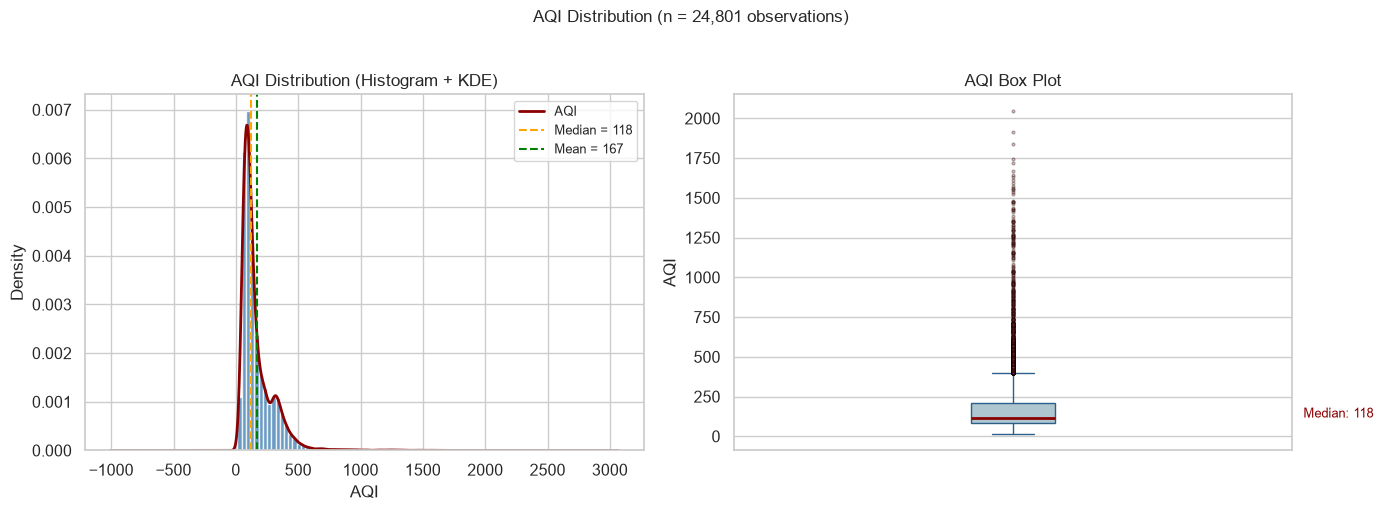

In [36]:
# ── AQI distribution: statistics + histogram + box plot ─────────────────────
df_aqi = df.dropna(subset=['AQI']).copy()  # supervised-learning subset (AQI present)

# Descriptive statistics
aqi_stats = df_aqi['AQI'].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.95])
aqi_skew  = df_aqi['AQI'].skew()
print('AQI Descriptive Statistics')
print('─' * 30)
for k, v in aqi_stats.items():
    print(f'  {k:<8}: {v:,.1f}')
print(f'  {"skewness":<8}: {aqi_skew:.3f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
ax = axes[0]
ax.hist(df_aqi['AQI'], bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
df_aqi['AQI'].plot.kde(ax=ax, color='darkred', linewidth=2)
ax.axvline(df_aqi['AQI'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median = {df_aqi["AQI"].median():.0f}')
ax.axvline(df_aqi['AQI'].mean(),   color='green',  linestyle='--', linewidth=1.5, label=f'Mean = {df_aqi["AQI"].mean():.0f}')
ax.set_xlabel('AQI')
ax.set_ylabel('Density')
ax.set_title('AQI Distribution (Histogram + KDE)')
ax.legend(fontsize=9)

# Box plot
ax2 = axes[1]
ax2.boxplot(df_aqi['AQI'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='#AEC6CF', color='#2c5f8a'),
            medianprops=dict(color='darkred', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.3, markerfacecolor='#d62728'),
            whiskerprops=dict(color='#2c5f8a'),
            capprops=dict(color='#2c5f8a'))
ax2.set_ylabel('AQI')
ax2.set_xticks([])
ax2.set_title('AQI Box Plot')
ax2.annotate(f'Median: {df_aqi["AQI"].median():.0f}', xy=(1.02, df_aqi['AQI'].median()),
             xycoords=('axes fraction', 'data'), fontsize=9, color='darkred')

plt.suptitle('AQI Distribution (n = {:,} observations)'.format(len(df_aqi)), y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**  
The AQI distribution is strongly **right-skewed** (skewness ≈ 3.4). The median AQI is 118 (Moderate band), while the mean is 167 — pulled upward by extreme events. The 75th percentile sits at 208 (Poor), meaning at least one quarter of all readings exceed the Poor threshold. The maximum recorded AQI is 2,049, reflecting severe industrial pollution spikes. This skewness has important implications for modelling: tree-based or robust regression methods will be more appropriate than linear models applied to raw AQI values.

### 10.3 AQI Category Distribution

`AQI_Bucket` divides AQI values into six ordinal categories defined by India's Central Pollution Control Board (CPCB): Good (0–50), Satisfactory (51–100), Moderate (101–200), Poor (201–300), Very Poor (301–400), and Severe (401+). This column is used **for descriptive analysis only** — it will not be used as a predictor variable in any machine-learning model, since it is directly derived from the AQI target.

AQI Category Distribution
              Count  Percentage (%) AQI Range
AQI_Bucket                                   
Good           1335           5.400      0–50
Satisfactory   8202          33.100    51–100
Moderate       8813          35.500   101–200
Poor           2778          11.200   201–300
Very Poor      2336           9.400   301–400
Severe         1337           5.400      401+



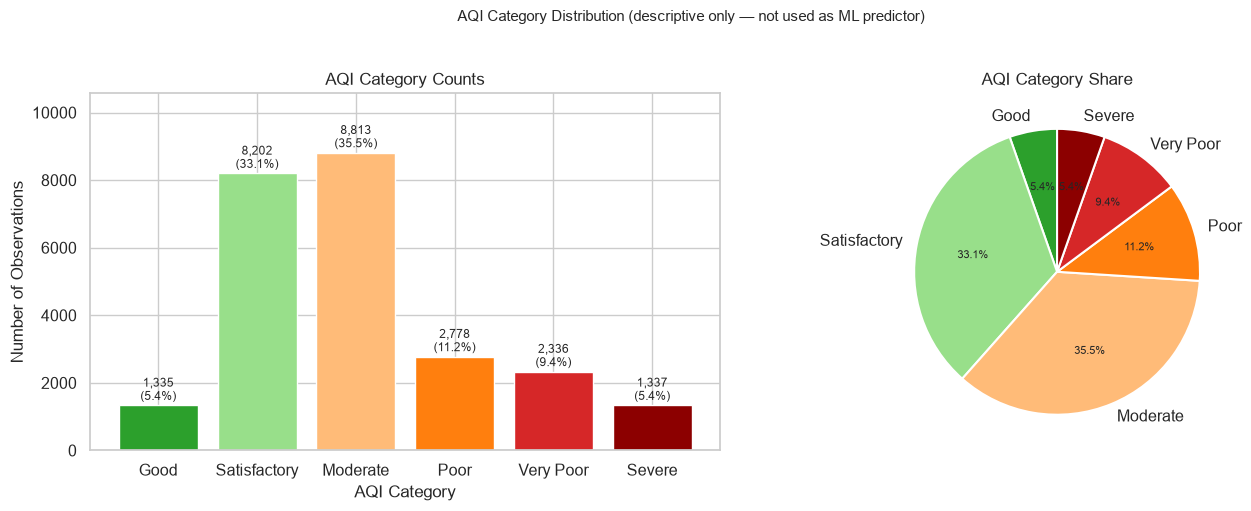

In [37]:
# ── AQI category distribution ────────────────────────────────────────────────
cat_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cat_counts = df_aqi['AQI_Bucket'].value_counts().reindex(cat_order)
cat_pct    = (cat_counts / cat_counts.sum() * 100).round(1)

# Summary table
cat_summary = pd.DataFrame({'Count': cat_counts, 'Percentage (%)': cat_pct})
cat_summary['AQI Range'] = ['0–50', '51–100', '101–200', '201–300', '301–400', '401+']
print('AQI Category Distribution')
print(cat_summary.to_string())
print()

# Colour palette: green → dark red
cat_colors = ['#2ca02c', '#98df8a', '#ffbb78', '#ff7f0e', '#d62728', '#8c0000']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
bars = ax.bar(cat_order, cat_counts.values, color=cat_colors, edgecolor='white')
for bar, cnt, pct in zip(bars, cat_counts.values, cat_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=8.5)
ax.set_xlabel('AQI Category')
ax.set_ylabel('Number of Observations')
ax.set_title('AQI Category Counts')
ax.set_ylim(0, cat_counts.max() * 1.2)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    cat_counts.values, labels=cat_order, colors=cat_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title('AQI Category Share')

plt.suptitle('AQI Category Distribution (descriptive only — not used as ML predictor)',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation:**  
The majority of observations fall in the **Moderate** (35.5%) and **Satisfactory** (33.1%) bands, together accounting for 68.6% of all days with a recorded AQI. Days classified as Good represent only 5.4% of the dataset — indicating that clean air is comparatively rare across the monitored cities. The Severe category (5.4%, 1,337 days) is as frequent as the Good category, reflecting the severity of pollution in the worst-affected urban centres.

### 10.4 City-Level AQI Analysis

Cities vary considerably in both the level and variability of their AQI. Because different cities have different numbers of observations (ranging from 111 to 1,999), comparisons are made on the **median** AQI rather than the mean, which is more robust to the extreme values present in this dataset. Observation counts are shown alongside each city.

In [38]:
# ── City-level AQI statistics ────────────────────────────────────────────────
city_stats = (
    df_aqi.groupby('City')['AQI']
    .agg(Median='median', Mean='mean', Min='min', Max='max', Count='count')
    .round(1)
    .sort_values('Median')
)
print('City-Level AQI Summary (sorted by median AQI):')
print(city_stats.to_string())

City-Level AQI Summary (sorted by median AQI):
                    Median    Mean    Min      Max  Count
City                                                     
Aizawl              23.000  34.800 18.000   92.000    111
Shillong            48.000  53.800 14.000  182.000    205
Thiruvananthapuram  68.000  75.900 32.000  230.000   1049
Coimbatore          75.000  73.100 26.000  120.000    343
Amaravati           78.000  95.300 24.000  312.000    840
Chandigarh          82.000  96.500 26.000  335.000    299
Bengaluru           86.000  94.400 20.000  352.000   1909
Mumbai              91.000 105.300 40.000  307.000    773
Kolkata             94.000 140.600 26.000  475.000    754
Ernakulam           94.500  92.600 55.000  180.000    152
Guwahati            98.000 140.100 25.000  956.000    495
Kochi               99.000 104.300 51.000  277.000    158
Chennai            100.000 114.500 30.000  449.000   1880
Amritsar           101.000 119.900 20.000  869.000   1119
Hyderabad          104.00

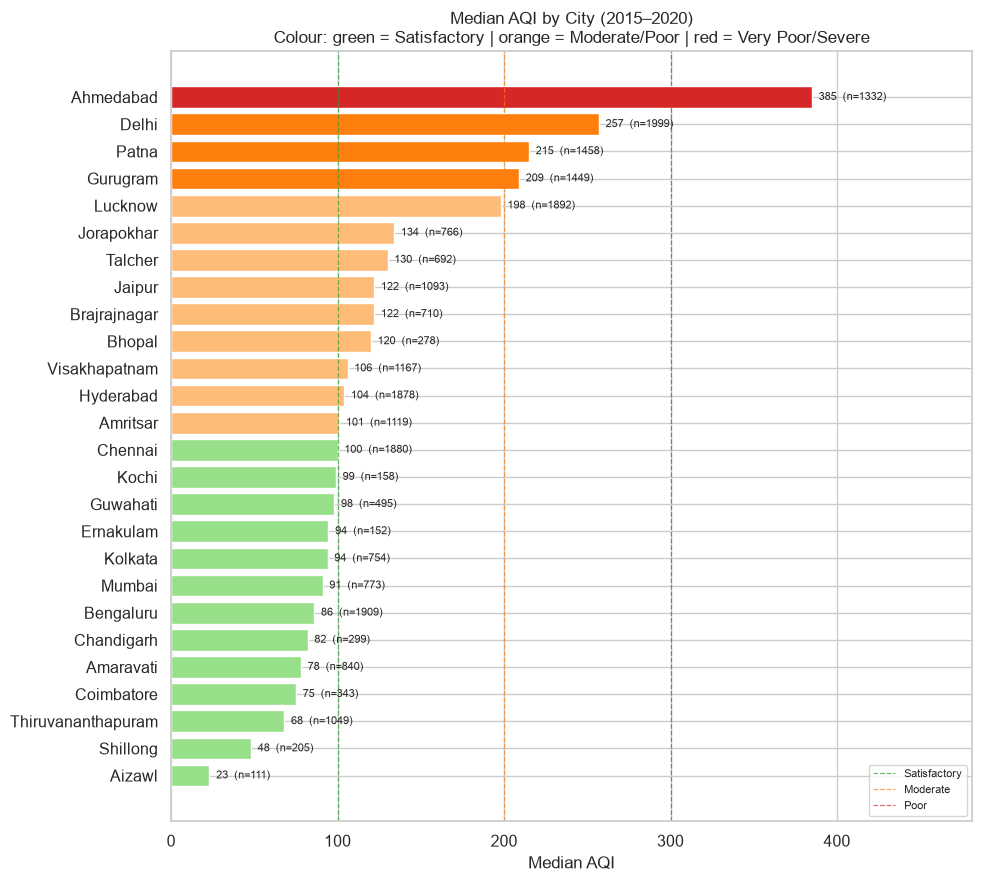

In [39]:
# ── Horizontal bar chart: median AQI by city ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

colors = ['#d62728' if m > 300 else '#ff7f0e' if m > 200
          else '#ffbb78' if m > 100 else '#98df8a'
          for m in city_stats['Median']]

bars = ax.barh(city_stats.index, city_stats['Median'], color=colors, edgecolor='white')
for bar, (_, row) in zip(bars, city_stats.iterrows()):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
            f'{row["Median"]:.0f}  (n={row["Count"]:.0f})',
            va='center', fontsize=8)

# AQI band reference lines
for val, label, clr in [(100, 'Satisfactory', '#2ca02c'), (200, 'Moderate', '#ff7f0e'),
                          (300, 'Poor', '#d62728')]:
    ax.axvline(val, linestyle='--', linewidth=0.9, color=clr, alpha=0.7, label=label)

ax.set_xlabel('Median AQI')
ax.set_title('Median AQI by City (2015–2020)\n'
             'Colour: green = Satisfactory | orange = Moderate/Poor | red = Very Poor/Severe')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, city_stats['Median'].max() * 1.25)
plt.tight_layout()
plt.show()

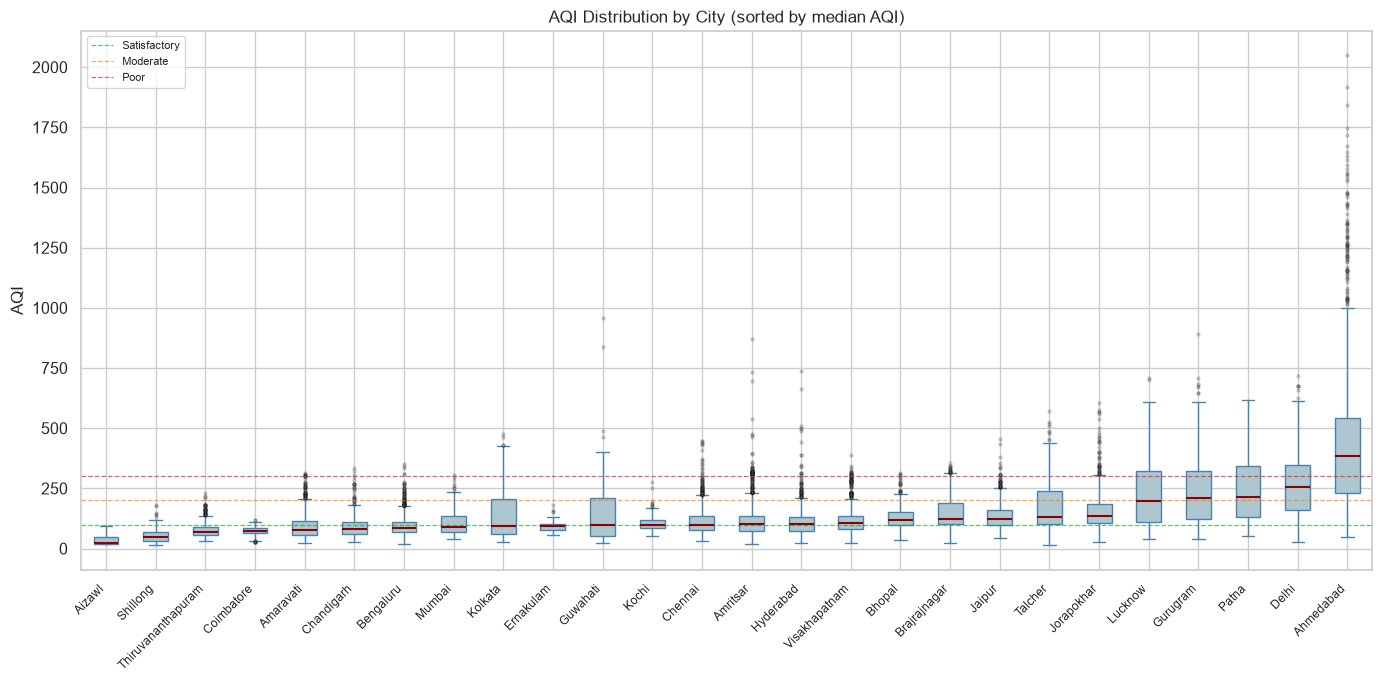

In [40]:
# ── Box plot: AQI distribution across cities ─────────────────────────────────
city_order = city_stats.index.tolist()  # sorted by median AQI

fig, ax = plt.subplots(figsize=(14, 7))
data_by_city = [df_aqi[df_aqi['City'] == city]['AQI'].values for city in city_order]
bp = ax.boxplot(data_by_city, tick_labels=city_order, patch_artist=True,
                medianprops=dict(color='darkred', linewidth=1.5),
                flierprops=dict(marker='o', markersize=2, alpha=0.2, markerfacecolor='grey'),
                boxprops=dict(facecolor='#AEC6CF', color='steelblue'),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'))
ax.set_xticklabels(city_order, rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('AQI')
ax.set_title('AQI Distribution by City (sorted by median AQI)')
for val, label, clr in [(100, 'Satisfactory', '#2ca02c'),
                          (200, 'Moderate', '#ff7f0e'),
                          (300, 'Poor', '#d62728')]:
    ax.axhline(val, linestyle='--', linewidth=0.9, color=clr, alpha=0.7, label=label)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:**  
There is a very large range in city-level air quality. **Aizawl** (Mizoram, north-east India) records the lowest median AQI (23 — Good) with only 111 valid observations, while **Ahmedabad** has the highest median (385 — Very Poor) and the widest spread, with a maximum of 2,049. **Delhi** (median 257 — Poor) and **Patna** (215 — Poor) are consistently among the most polluted large cities. Southern coastal cities such as Thiruvananthapuram, Coimbatore, and Bengaluru sit in the Satisfactory band.  

**Caveat:** Cities with fewer observations (e.g., Aizawl with 111, Shillong with 205) may not fully capture seasonal peaks, so their medians should be interpreted cautiously.

### 10.5 Temporal Analysis

We investigate how AQI has changed year-on-year and whether systematic monthly/seasonal patterns are present. Median AQI is used to reduce the influence of extreme episodes.

Yearly Median / Mean AQI:
      median    mean  count
Year                       
2015 175.000 212.600   1825
2016 149.000 197.700   2560
2017 130.000 181.600   3231
2018 124.000 182.800   5710
2019 109.000 156.600   7061
2020  93.000 113.600   4414

Monthly Median / Mean AQI:
       median    mean
Month                
Jan   183.000 231.700
Feb   150.000 203.100
Mar   124.000 164.800
Apr   111.000 143.400
May   111.000 135.500
Jun    96.000 120.300
Jul    86.000 111.900
Aug    85.000 113.700
Sep    88.000 115.300
Oct   130.000 188.800
Nov   185.000 241.600
Dec   182.000 227.200


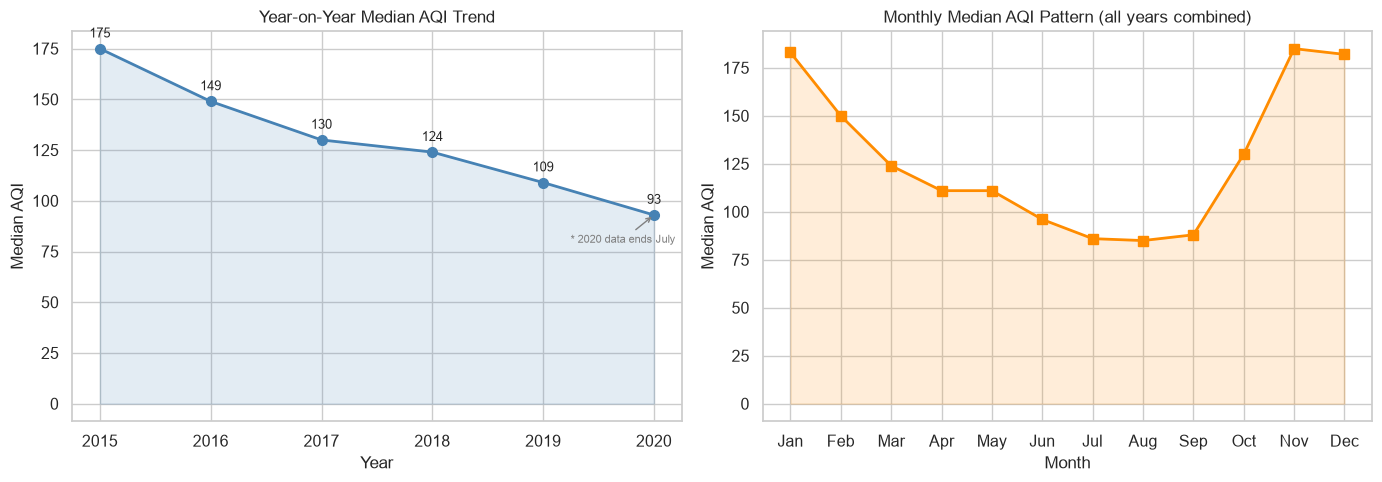

In [41]:
# ── Yearly and monthly AQI trends ────────────────────────────────────────────
yearly_aqi  = df_aqi.groupby('Year')['AQI'].agg(['median', 'mean', 'count']).round(1)
monthly_aqi = df_aqi.groupby('Month')['AQI'].agg(['median', 'mean']).round(1)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print('Yearly Median / Mean AQI:')
print(yearly_aqi.to_string())
print()
print('Monthly Median / Mean AQI:')
print(monthly_aqi.rename(index=dict(enumerate(month_labels, 1))).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yearly trend
ax = axes[0]
ax.plot(yearly_aqi.index, yearly_aqi['median'], marker='o', color='steelblue',
        linewidth=2, markersize=7, label='Median AQI')
ax.fill_between(yearly_aqi.index, yearly_aqi['median'], alpha=0.15, color='steelblue')
for yr, row in yearly_aqi.iterrows():
    ax.annotate(f'{row["median"]:.0f}', (yr, row['median']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set_xlabel('Year')
ax.set_ylabel('Median AQI')
ax.set_title('Year-on-Year Median AQI Trend')
ax.set_xticks(yearly_aqi.index)
ax.annotate('* 2020 data ends July', xy=(2020, yearly_aqi.loc[2020,'median']),
            xytext=(-60, -20), textcoords='offset points', fontsize=8, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey'))

# Monthly pattern
ax2 = axes[1]
ax2.plot(range(1, 13), monthly_aqi['median'], marker='s', color='darkorange',
         linewidth=2, markersize=7, label='Median AQI')
ax2.fill_between(range(1, 13), monthly_aqi['median'], alpha=0.15, color='darkorange')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels)
ax2.set_xlabel('Month')
ax2.set_ylabel('Median AQI')
ax2.set_title('Monthly Median AQI Pattern (all years combined)')

plt.tight_layout()
plt.show()

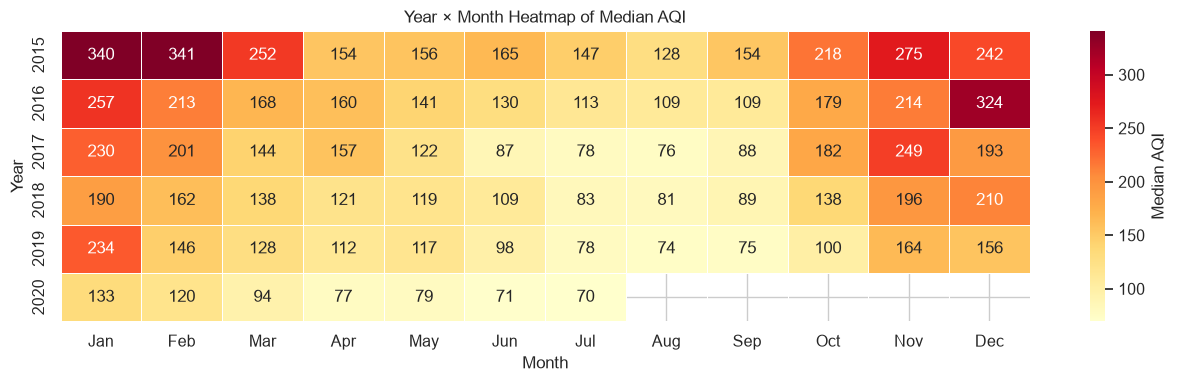

In [42]:
# ── Year × Month AQI heatmap ─────────────────────────────────────────────────
ym_pivot = df_aqi.groupby(['Year', 'Month'])['AQI'].median().unstack()
ym_pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(ym_pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': 'Median AQI'})
ax.set_title('Year × Month Heatmap of Median AQI')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

**Interpretation:**  
**Year-on-year trend:** Median AQI has declined consistently from 175 (2015) to 93 (2020). However, the 2020 data covers only January–July, which captures the post-monsoon winter peak (January) but misses the full year. The apparent improvement is therefore partly attributable to the 2020 COVID-19 lockdowns reducing industrial and vehicular emissions, and partly to incomplete year coverage.  

**Monthly pattern:** A strong U-shaped pattern is visible. AQI peaks in winter (November–January, median ~183–185), drops sharply through the monsoon (July–August, ~85–86), and rises again in post-monsoon October (130). This is consistent with: (i) stagnant winter air that traps pollutants, (ii) crop-residue burning in October–November, and (iii) monsoon rains washing pollutants from the atmosphere in summer.  

The year × month heatmap confirms this pattern holds across all years, with the highest cells consistently in Jan–Feb and Nov–Dec.

### 10.6 Seasonal Analysis

A `Season` feature is defined using standard Indian meteorological groupings:

| Season | Months | Characteristics |
|---|---|---|
| **Winter** | Dec, Jan, Feb | Cold, stable air; trapped pollutants; crop burning in N. India |
| **Spring / Pre-Monsoon** | Mar, Apr, May | Warming, drier; dust storms in western India |
| **Monsoon** | Jun, Jul, Aug, Sep | Rain washes pollutants; lowest AQI period |
| **Post-Monsoon / Autumn** | Oct, Nov | Harvest burning; fog begins; AQI rises sharply |

AQI by Season:
                     Median    Mean     Std  Count
Season                                            
Winter              171.000 220.700 157.300   6237
Spring/Pre-Monsoon  116.000 147.700 116.500   7057
Monsoon              89.000 115.600  96.700   7690
Post-Monsoon/Autumn 154.000 215.500 177.000   3817


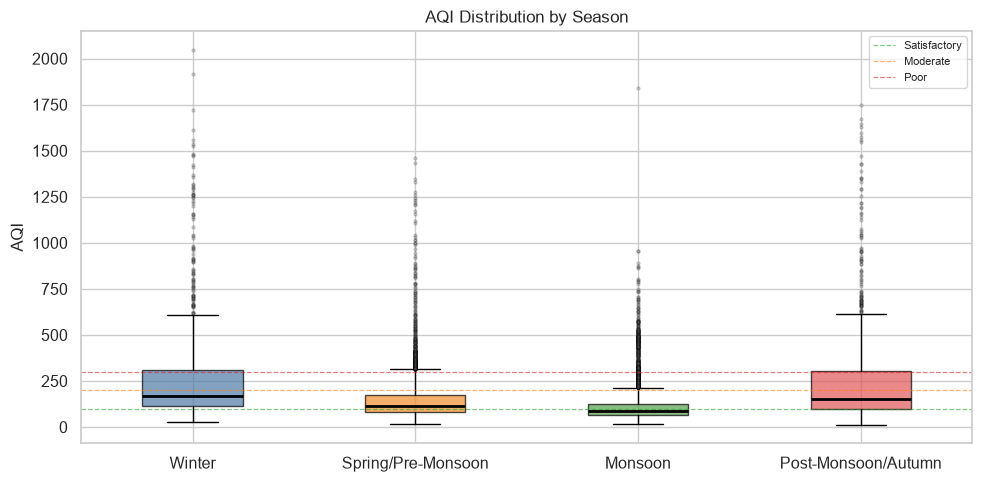

In [43]:
# ── Season feature + AQI comparison ─────────────────────────────────────────
def assign_season(month):
    if month in [12, 1, 2]:    return 'Winter'
    if month in [3, 4, 5]:     return 'Spring/Pre-Monsoon'
    if month in [6, 7, 8, 9]:  return 'Monsoon'
    return 'Post-Monsoon/Autumn'

df['Season']     = df['Month'].map(assign_season)
df_aqi['Season'] = df_aqi['Month'].map(assign_season)

season_order = ['Winter', 'Spring/Pre-Monsoon', 'Monsoon', 'Post-Monsoon/Autumn']

season_stats = (
    df_aqi.groupby('Season')['AQI']
    .agg(Median='median', Mean='mean', Std='std', Count='count')
    .round(1)
    .reindex(season_order)
)
print('AQI by Season:')
print(season_stats.to_string())

# Box plot by season
fig, ax = plt.subplots(figsize=(10, 5))
season_colors = ['#4e79a7', '#f28e2c', '#59a14f', '#e15759']
data_by_season = [df_aqi[df_aqi['Season'] == s]['AQI'].values for s in season_order]
bp = ax.boxplot(data_by_season, tick_labels=season_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.2, markerfacecolor='grey'))
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('AQI')
ax.set_title('AQI Distribution by Season')
for val, label, clr in [(100,'Satisfactory','#2ca02c'),
                          (200,'Moderate','#ff7f0e'),
                          (300,'Poor','#d62728')]:
    ax.axhline(val, linestyle='--', linewidth=0.9, color=clr, alpha=0.6, label=label)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:**  
The Monsoon season has by far the lowest median AQI (89 — Satisfactory), while Winter and Post-Monsoon seasons both exceed the Moderate threshold (medians 171 and 154). The Winter season also shows the highest variance, driven by extreme pollution events in northern cities. The Monsoon–Winter contrast is approximately 2× in median AQI terms (89 vs. 171), reflecting the dominant role of rainfall and atmospheric stability in determining pollution levels.

### 10.7 Pollutant Distributions

The eleven retained pollutant columns span very different concentration scales and units. Several are strongly right-skewed. Visualisations use a **log₁₀ scale on the x-axis** where distributions are heavily skewed, making the full range visible without distorting the bulk of the data. The underlying data values are **not transformed** — only the axis is scaled for display.

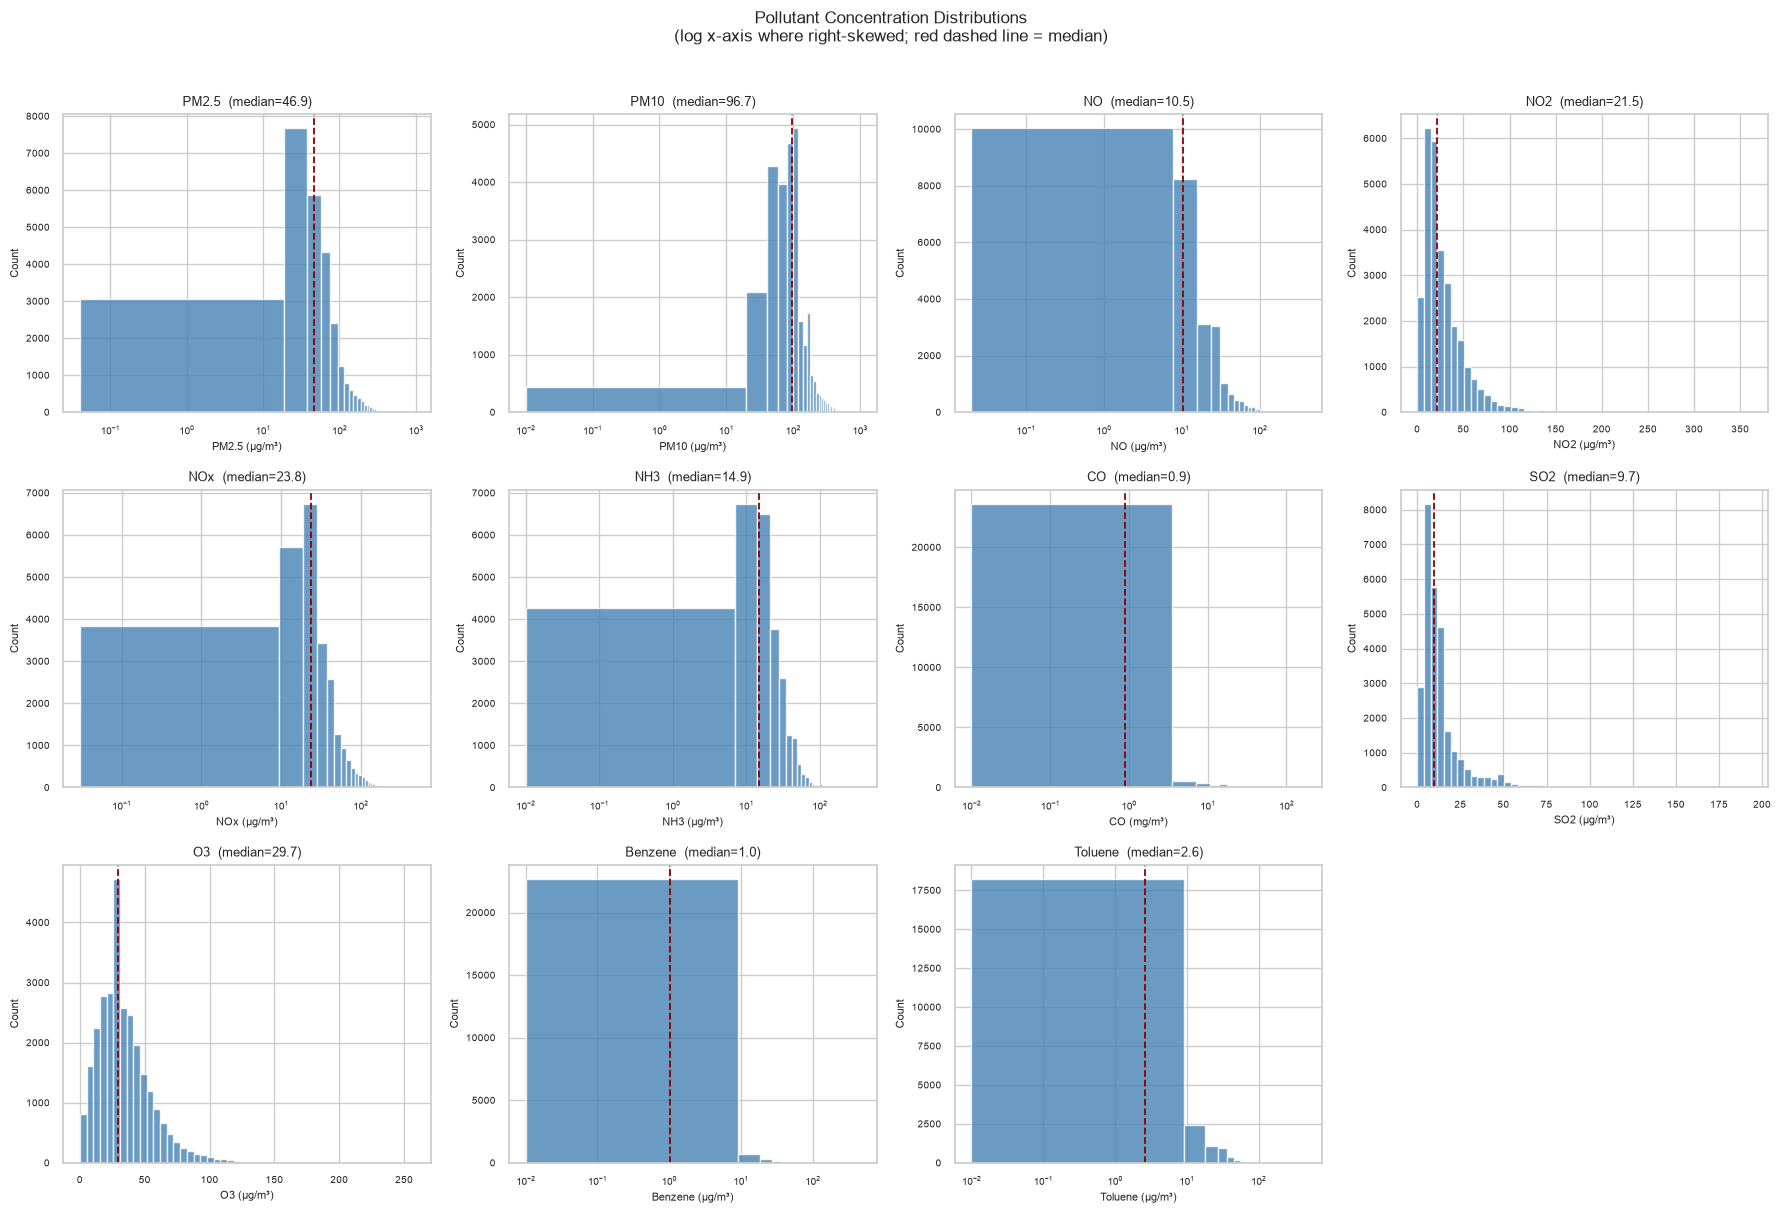

In [44]:
# ── Pollutant distribution histograms (log x-axis for skewed cols) ───────────
POLL11 = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']
# Columns with heavy right skew benefit from log x-axis
log_cols = {'PM2.5','PM10','NO','NOx','NH3','CO','Benzene','Toluene'}

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(POLL11):
    ax = axes[i]
    data = df[col].dropna()
    # Shift to avoid log(0); only needed for cols with 0 values
    if col in log_cols:
        data_plot = data[data > 0]
        ax.hist(data_plot, bins=50, log=False, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_xscale('log')
    else:
        ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    med = data.median()
    ax.axvline(med, color='darkred', linestyle='--', linewidth=1.3)
    ax.set_title(f'{col}  (median={med:.1f})', fontsize=9)
    ax.set_xlabel(f'{col} (µg/m³)' if col not in ['CO'] else 'CO (mg/m³)', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Pollutant Concentration Distributions\n'
             '(log x-axis where right-skewed; red dashed line = median)',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**  
All pollutants except O3 are right-skewed. PM2.5 and PM10 span three orders of magnitude (roughly 1–1,000 µg/m³), reflecting the enormous range from clean hill cities to heavily industrialised centres. CO and Benzene are particularly concentrated near zero with long tails. O3 has a comparatively symmetric distribution, centred around 30 µg/m³. These distributions confirm that median-based imputation (Stage 2) was appropriate — mean-based imputation would have been pulled upward by extreme values.

### 10.8 Pollutant–AQI Relationships

Understanding which pollutants are most strongly associated with AQI is essential for both interpretation and feature selection in the ML stage. We first compute Pearson correlations, then examine scatter plots for the strongest predictors.  

**Important:** Correlation measures linear association. A high correlation between a pollutant and AQI does not imply that the pollutant *causes* the AQI value — multiple pollutants are typically co-emitted, and AQI itself is computed from a sub-index formula rather than a simple weighted sum.

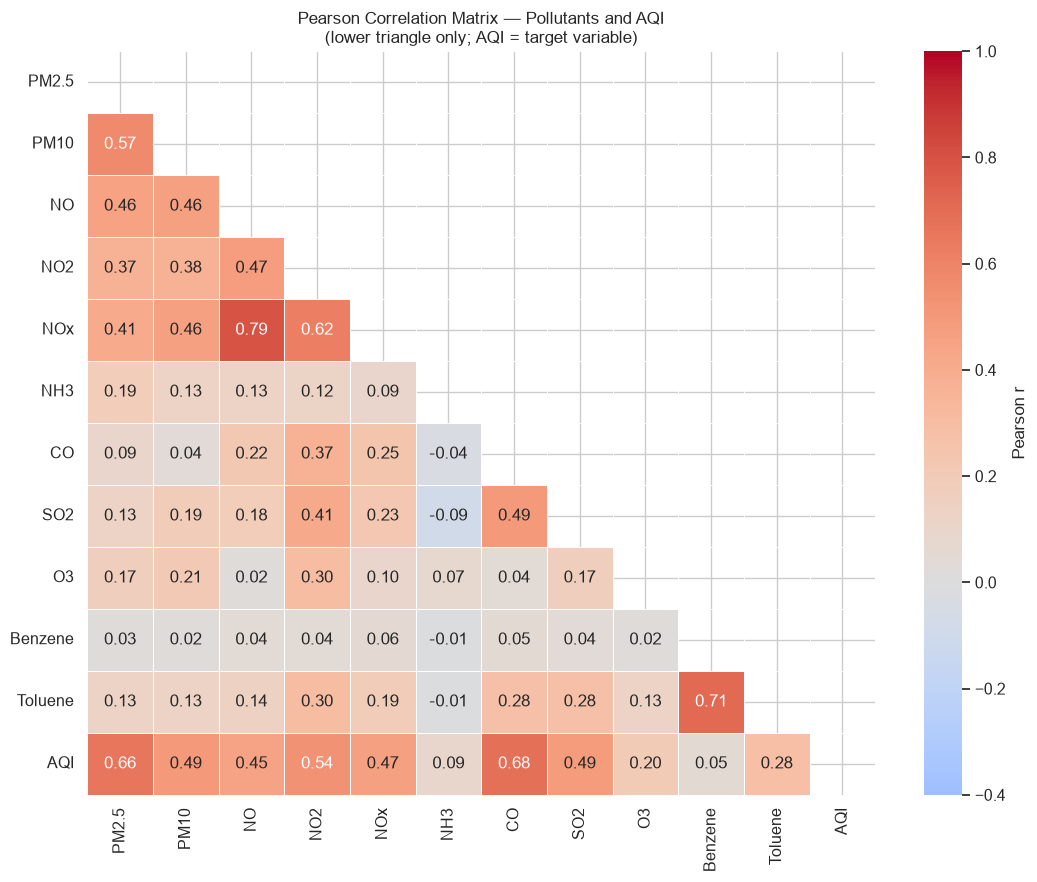

Pearson correlation with AQI (ranked):
  CO        : +0.678  █████████████
  PM2.5     : +0.657  █████████████
  NO2       : +0.535  ██████████
  PM10      : +0.494  █████████
  SO2       : +0.486  █████████
  NOx       : +0.468  █████████
  NO        : +0.451  █████████
  Toluene   : +0.284  █████
  O3        : +0.198  ███
  NH3       : +0.092  █
  Benzene   : +0.049  


In [45]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
corr_cols = POLL11 + ['AQI']
corr_matrix = df_aqi[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.4, linecolor='white',
            ax=ax, cbar_kws={'label': 'Pearson r'},
            vmin=-0.4, vmax=1.0)
ax.set_title('Pearson Correlation Matrix — Pollutants and AQI\n'
             '(lower triangle only; AQI = target variable)')
plt.tight_layout()
plt.show()

# Print AQI correlations ranked
aqi_corr = corr_matrix['AQI'].drop('AQI').sort_values(ascending=False)
print('Pearson correlation with AQI (ranked):')
for col, r in aqi_corr.items():
    bar = '█' * int(abs(r) * 20)
    print(f'  {col:<10}: {r:+.3f}  {bar}')

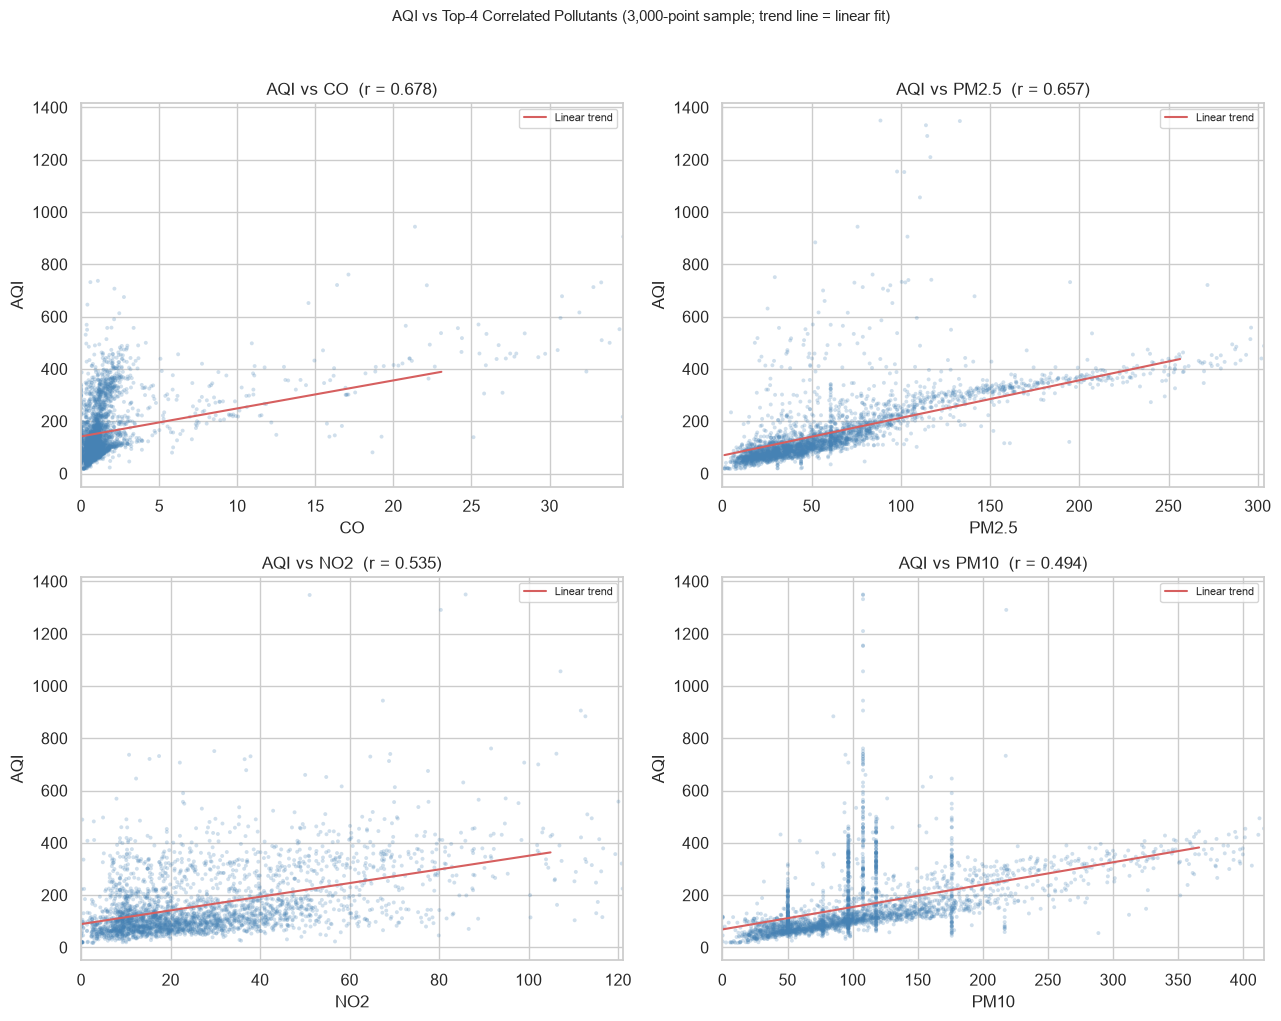

In [46]:
# ── Scatter plots: top-4 correlated pollutants vs AQI ────────────────────────
top_poll = ['CO', 'PM2.5', 'NO2', 'PM10']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(top_poll):
    ax = axes[i]
    sample = df_aqi[['AQI', col]].dropna().sample(
        n=min(3000, len(df_aqi)), random_state=42)
    ax.scatter(sample[col], sample['AQI'],
               alpha=0.25, s=8, color='steelblue', edgecolors='none')
    # Trend line using numpy polyfit
    z = np.polyfit(sample[col], sample['AQI'], 1)
    p = np.poly1d(z)
    xs = np.linspace(sample[col].min(), sample[col].quantile(0.98), 100)
    ax.plot(xs, p(xs), 'r-', linewidth=1.5, label='Linear trend')
    r = df_aqi[[col, 'AQI']].corr().loc[col, 'AQI']
    ax.set_xlabel(col)
    ax.set_ylabel('AQI')
    ax.set_title(f'AQI vs {col}  (r = {r:.3f})')
    ax.legend(fontsize=8)
    # Cap x-axis at 99th percentile for readability
    ax.set_xlim(0, sample[col].quantile(0.99))

plt.suptitle('AQI vs Top-4 Correlated Pollutants (3,000-point sample; trend line = linear fit)',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

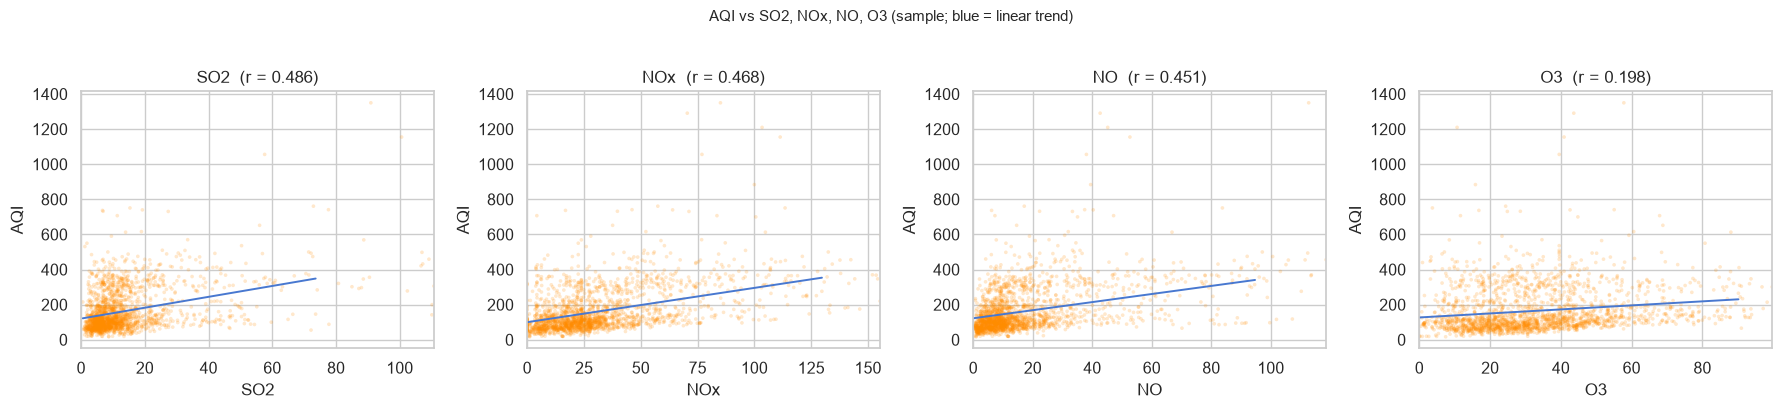

In [47]:
# ── Scatter: remaining notable pollutants ─────────────────────────────────────
other_poll = ['SO2', 'NOx', 'NO', 'O3']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(other_poll):
    ax = axes[i]
    sample = df_aqi[['AQI', col]].dropna().sample(
        n=min(2000, len(df_aqi)), random_state=42)
    ax.scatter(sample[col], sample['AQI'],
               alpha=0.2, s=7, color='darkorange', edgecolors='none')
    z = np.polyfit(sample[col], sample['AQI'], 1)
    xs = np.linspace(sample[col].min(), sample[col].quantile(0.98), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'b-', linewidth=1.4)
    r = df_aqi[[col, 'AQI']].corr().loc[col, 'AQI']
    ax.set_xlabel(col)
    ax.set_ylabel('AQI')
    ax.set_title(f'{col}  (r = {r:.3f})')
    ax.set_xlim(0, sample[col].quantile(0.99))

plt.suptitle('AQI vs SO2, NOx, NO, O3 (sample; blue = linear trend)',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation:**  
**CO** (r = 0.678) and **PM2.5** (r = 0.657) are the two pollutants most strongly correlated with AQI. **NO2** (r = 0.535), **PM10** (r = 0.494), **SO2** (r = 0.486), and **NOx** (r = 0.468) also show moderate positive correlations.  

**Benzene** (r = 0.049) and **NH3** (r = 0.092) have near-zero correlations with AQI, suggesting they are less informative as standalone predictors.  

The scatter plots show that while a positive trend is clear, the relationships are non-linear and highly scattered — especially for extreme AQI values. This suggests that a non-linear model (e.g., Random Forest) should outperform simple linear regression.  

Note also that NOx is highly correlated with NO (r ≈ 0.79), and Benzene is highly correlated with Toluene (r ≈ 0.71), indicating multicollinearity that will need attention in the ML stage.

### 10.9 City × Pollutant Analysis

To understand what drives city-level AQI differences, we examine how median concentrations of key pollutants vary across cities. Each cell in the heatmap shows the median value of a pollutant for a given city, scaled column-wise (z-score) so that cities can be compared relative to the national median regardless of the absolute units of each pollutant.

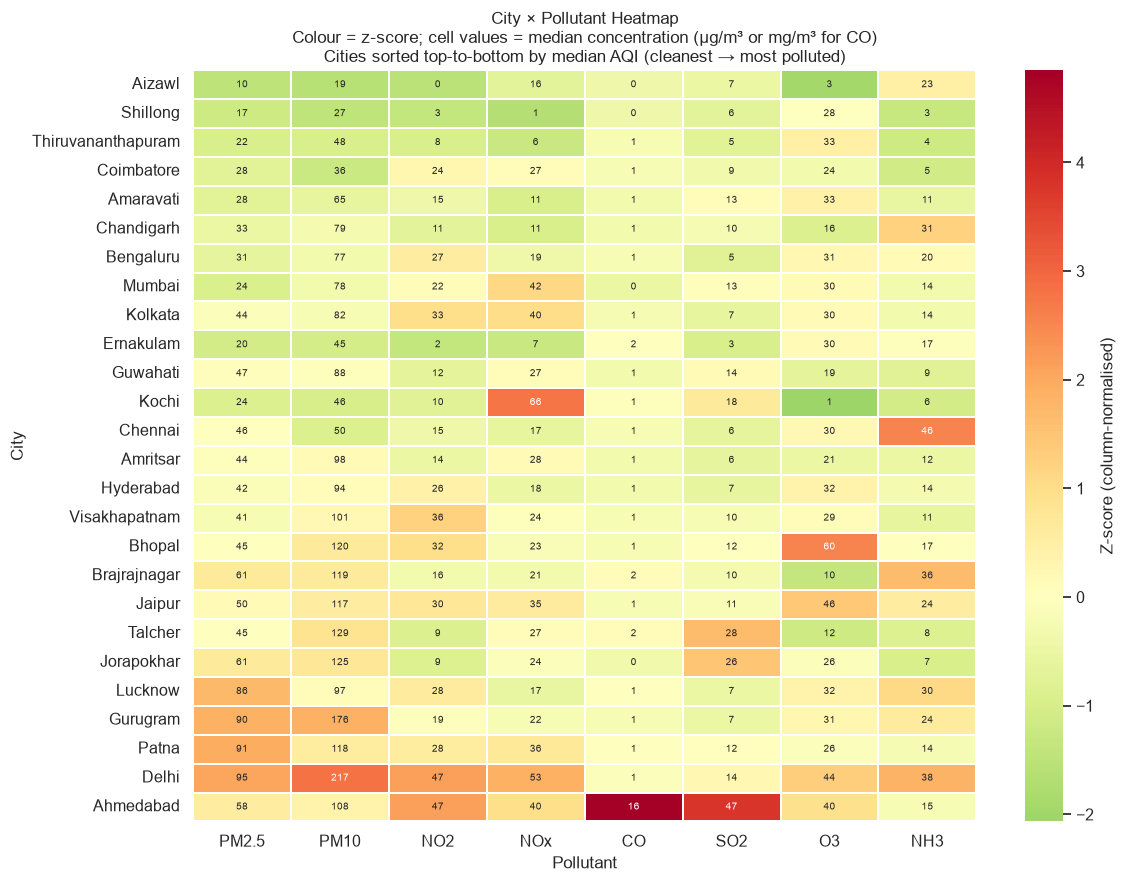


City × Pollutant Median Concentrations (raw values):
                    PM2.5    PM10    NO2    NOx     CO    SO2     O3    NH3
City                                                                       
Aizawl             10.500  19.000  0.300 15.500  0.300  7.400  2.700 22.700
Shillong           17.400  26.900  2.700  1.100  0.200  6.000 27.600  2.800
Thiruvananthapuram 22.400  48.300  7.600  6.400  0.900  5.400 33.400  4.000
Coimbatore         28.500  36.200 24.000 27.400  0.900  8.900 23.600  4.800
Amaravati          28.000  64.900 15.400 11.000  0.600 13.000 33.000 11.300
Chandigarh         33.300  78.900 11.300 10.800  0.600 10.000 16.400 31.100
Bengaluru          30.900  77.400 26.900 19.100  0.900  5.000 30.600 19.600
Mumbai             23.700  77.900 21.500 41.900  0.000 12.700 29.600 14.000
Kolkata            43.600  81.800 32.600 40.100  0.700  6.800 30.100 13.600
Ernakulam          19.800  44.600  2.500  6.800  1.500  3.300 29.700 16.600
Guwahati           46.800  88.000 

In [48]:
# ── City × Pollutant heatmap (z-score normalised per column) ─────────────────
focus_polls = ['PM2.5', 'PM10', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'NH3']

city_poll_med = (
    df.groupby('City')[focus_polls]
    .median()
    .round(1)
)
# Z-score normalise each column
city_poll_z = (city_poll_med - city_poll_med.mean()) / city_poll_med.std()

# Sort cities by their mean normalised score (overall pollution level)
city_poll_z = city_poll_z.loc[city_stats.index]  # match AQI-sorted order

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(city_poll_z, cmap='RdYlGn_r', center=0,
            annot=city_poll_med.loc[city_poll_z.index, focus_polls],
            fmt='.0f', linewidths=0.3, linecolor='white',
            ax=ax, cbar_kws={'label': 'Z-score (column-normalised)'},
            annot_kws={'size': 7})
ax.set_title('City × Pollutant Heatmap\n'
             'Colour = z-score; cell values = median concentration (µg/m³ or mg/m³ for CO)\n'
             'Cities sorted top-to-bottom by median AQI (cleanest → most polluted)')
ax.set_xlabel('Pollutant')
ax.set_ylabel('City')
plt.tight_layout()
plt.show()

print('\nCity × Pollutant Median Concentrations (raw values):')
print(city_poll_med.loc[city_poll_z.index].to_string())

**Interpretation:**  
The heatmap reveals distinct pollution profiles across cities:  

- **Delhi and Gurugram** stand out with extremely high PM2.5 and PM10 — Delhi's median PM2.5 is 94.6 µg/m³, nearly 4× the national median.  
- **Ahmedabad** has uniquely high CO (16.2 mg/m³) and SO2 (46.8 µg/m³), suggesting a different emission source mix (industrial/combustion-heavy) compared to Delhi's particulate-dominated profile.  
- **Kochi** shows anomalously high NO (68.6 µg/m³) despite a moderate overall AQI — possibly reflecting local traffic or industrial NO sources that do not translate proportionally to AQI.  
- **Aizawl and Shillong** (north-east India, hilly terrain) have consistently low concentrations across all pollutants.  
- **SO2 is elevated in industrial cities** (Ahmedabad, Talcher, Jorapokhar) — consistent with coal-fired power plants and heavy industries in those locations.

### 10.10 Key Findings from EDA

The following findings are all grounded in quantitative results from the analysis above.

---

**1. Strongly right-skewed AQI distribution**  
AQI has a median of 118 (Moderate) but a mean of 167, pulled upward by extreme events (max = 2,049). Skewness = 3.4. This means the majority of days are in the Moderate or Satisfactory range, but severe episodes can be far beyond the nominal scale maximum of 500.

**2. Most days are Moderate or Satisfactory**  
68.6% of observations fall in the Moderate (35.5%) or Satisfactory (33.1%) categories. Only 5.4% are classified as Good — as rare as the Severe category (5.4%).

**3. Extreme city-level disparity**  
Median AQI ranges from 23 (Aizawl — Good) to 385 (Ahmedabad — Very Poor). Delhi (median 257), Patna (215), Gurugram (209), and Lucknow (198) form a high-pollution cluster, while southern and north-eastern cities are substantially cleaner.

**4. Consistent declining trend (2015–2019), disrupted in 2020**  
Median AQI fell from 175 (2015) to 109 (2019), a 38% reduction over four years. The 2020 median of 93 must be interpreted cautiously — data ends in July, missing the autumn/winter peaks, and COVID lockdowns suppressed emissions.

**5. Strong seasonal cycle**  
Monsoon AQI (median 89) is roughly half of Winter AQI (median 171). Post-monsoon October–November shows a sharp AQI spike associated with crop-residue burning and the onset of winter atmospheric conditions.

**6. CO and PM2.5 are the strongest AQI predictors**  
Pearson correlation with AQI: CO (r = 0.678), PM2.5 (r = 0.657), NO2 (r = 0.535), PM10 (r = 0.494). Benzene (r = 0.049) and NH3 (r = 0.092) show near-zero linear association.

**7. Non-linear pollutant–AQI relationships**  
Scatter plots show that while positive trends exist, the relationship between pollutants and AQI is non-linear and highly variable — particularly at extreme values. This motivates the use of non-linear ML models (e.g., Random Forest) in Stage 5.

**8. Multicollinearity between pollutant pairs**  
NOx and NO are highly correlated (r ≈ 0.79); Benzene and Toluene (r ≈ 0.71). In the ML stage, feature selection or regularisation will be needed to address this.

**9. Distinct city pollution profiles**  
Delhi's pollution is particulate-dominated (high PM2.5, PM10); Ahmedabad's is combustion-dominated (very high CO, SO2); Kochi shows anomalously high NO. These differences suggest that a single national model may benefit from city as a feature.

**10. Data coverage is uneven across cities**  
Observation counts range from 111 (Aizawl) to 1,999 (Delhi). City-level conclusions for sparsely covered cities should be interpreted with caution.

---

## 11. Feature Engineering and ML Dataset Preparation

This section transforms the cleaned dataset into a machine-learning-ready format. Every design decision is documented and justified. The goal is to produce a training and test dataset that can be fed directly into regression models in Stage 5, without any data leakage or methodological errors.

### 11.1 Define the ML Problem

| Attribute | Value |
|---|---|
| **Task** | Supervised regression |
| **Target variable** | `AQI` (continuous, numeric) |
| **Objective** | Predict the daily Air Quality Index for a given city from measurable pollutant concentrations and temporal/spatial features |
| **Evaluation** | MAE, RMSE, R² (details in Stage 5) |

**Why AQI_Bucket is excluded from predictors:**  
`AQI_Bucket` is computed directly from the `AQI` value by applying fixed threshold bands. Using it as a feature when predicting `AQI` would be **target leakage** — the model would have access to a recoded version of the answer. Any model trained with `AQI_Bucket` as a feature would show artificially inflated performance that would not generalise to real-world deployment, where `AQI_Bucket` is only known *after* AQI is computed.

**Why rows with missing AQI are excluded from supervised training:**  
Machine-learning regression requires a known, real label for every training observation. Rows where `AQI` is `NaN` have no valid target — imputing the target would mean training a model to predict values we invented ourselves, which invalidates evaluation metrics. These rows were retained in `df` for descriptive analysis but will not appear in `df_model`.

### 11.2 Build the Modeling Dataset

A dedicated modeling DataFrame `df_model` is constructed from the cleaned `df` by retaining only rows where `AQI` is available and sorting chronologically. This is the canonical dataset used from this point forward.

In [49]:
# ── Build dedicated modeling DataFrame ───────────────────────────────────────
# Start from the cleaned working dataframe (already in memory from Stage 2).
# Drop rows where AQI is NaN — these cannot be used for supervised regression.
df_model = (
    df.dropna(subset=['AQI'])
    .copy()
    .sort_values('Date')
    .reset_index(drop=True)
)

print(f'Rows in cleaned df        : {len(df):,}')
print(f'Rows with missing AQI     : {df["AQI"].isna().sum():,}  (excluded from modeling)')
print(f'Rows in df_model          : {len(df_model):,}')
print(f'Date range of df_model    : {df_model["Date"].min().date()} → {df_model["Date"].max().date()}')
print(f'Unique cities in df_model : {df_model["City"].nunique()}')
print()
print('Columns in df_model:')
print(list(df_model.columns))

Rows in cleaned df        : 28,108
Rows with missing AQI     : 3,307  (excluded from modeling)
Rows in df_model          : 24,801
Date range of df_model    : 2015-01-01 → 2020-07-01
Unique cities in df_model : 26

Columns in df_model:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket', 'Year', 'Month', 'Month_Name', 'Quarter', 'DayOfYear', 'Season']


### 11.3 Temporal Feature Engineering

The `Date` column is a rich source of signal for AQI prediction. We already extracted `Year`, `Month`, `Quarter`, and `DayOfYear` in Stage 2. Here we add two further features:

- **`Day`** — day of month (1–31)
- **`DayOfWeek`** — weekday number (0 = Monday … 6 = Sunday); weekday vs weekend traffic patterns can affect pollution levels

**Cyclical encoding for month and day-of-year:**

Treating `Month` as a raw integer (1–12) implies that December (12) and January (1) are far apart, when in reality they are adjacent seasons. A linear model or distance-based model would then be misled by this artificial discontinuity. Cyclical (sine/cosine) encoding maps the feature onto a unit circle, preserving the cyclic structure:

> `month_sin = sin(2π × month / 12)`  
> `month_cos = cos(2π × month / 12)`

The same approach is applied to `DayOfYear` (period 365). The raw integer versions are also retained because tree-based models can sometimes exploit ordinal information directly.

In [50]:
# ── Temporal feature engineering ─────────────────────────────────────────────
import numpy as np

# Additional temporal fields not yet in df_model
df_model['Day']        = df_model['Date'].dt.day
df_model['DayOfWeek']  = df_model['Date'].dt.dayofweek   # 0=Mon … 6=Sun

# Cyclical encoding for Month (period = 12)
df_model['month_sin']  = np.sin(2 * np.pi * df_model['Month']  / 12)
df_model['month_cos']  = np.cos(2 * np.pi * df_model['Month']  / 12)

# Cyclical encoding for DayOfYear (period = 365)
df_model['doy_sin']    = np.sin(2 * np.pi * df_model['DayOfYear'] / 365)
df_model['doy_cos']    = np.cos(2 * np.pi * df_model['DayOfYear'] / 365)

# Verify
print('New temporal features added:')
check_cols = ['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear',
              'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'Season']
print(df_model[check_cols].head(6).to_string())
print()
print('Value ranges:')
for col in ['month_sin','month_cos','doy_sin','doy_cos']:
    print(f'  {col:<14}: min={df_model[col].min():.4f}  max={df_model[col].max():.4f}')

New temporal features added:
        Date  Year  Month  Day  DayOfWeek  DayOfYear  month_sin  month_cos  doy_sin  doy_cos  Season
0 2015-01-01  2015      1    1          3          1      0.500      0.866    0.017    1.000  Winter
1 2015-01-02  2015      1    2          4          2      0.500      0.866    0.034    0.999  Winter
2 2015-01-03  2015      1    3          5          3      0.500      0.866    0.052    0.999  Winter
3 2015-01-04  2015      1    4          6          4      0.500      0.866    0.069    0.998  Winter
4 2015-01-05  2015      1    5          0          5      0.500      0.866    0.086    0.996  Winter
5 2015-01-06  2015      1    6          1          6      0.500      0.866    0.103    0.995  Winter

Value ranges:
  month_sin     : min=-1.0000  max=1.0000
  month_cos     : min=-1.0000  max=1.0000
  doy_sin       : min=-1.0000  max=1.0000
  doy_cos       : min=-1.0000  max=1.0000


The cyclical sin/cos pair for Month places January and December adjacent on the unit circle, correctly representing the continuity of winter. A pure ordinal encoding would place a gap of 11 units between month 1 and month 12, which is physically incorrect for a seasonal signal.

### 11.4 City Encoding

`City` is a nominal categorical variable with 26 levels. It must be converted to numeric form before being passed to scikit-learn estimators.

**One-hot encoding** is used. This creates a binary indicator column for each city, with `drop='first'` to avoid perfect multicollinearity (the dropped category becomes the implicit reference level). This yields 25 binary columns.

**Why not target encoding?**  
Target encoding (replacing city names with the city's mean/median AQI) would constitute **target leakage**: the encoding would embed information about the target variable `AQI` directly into a feature. This would produce misleading performance metrics. One-hot encoding is leakage-free because it encodes identity only, not outcome.

In [51]:
# ── City one-hot encoding (preview only — actual OHE applied in pipeline) ────
# We demonstrate the encoding shape here; the Pipeline in §11.7 applies it
# correctly, fitting only on training data.

from sklearn.preprocessing import OneHotEncoder
_ohe_demo = OneHotEncoder(drop='first', sparse_output=False)
_city_demo = _ohe_demo.fit_transform(df_model[['City']])
_city_cols  = _ohe_demo.get_feature_names_out(['City'])

print(f'Number of cities         : {df_model["City"].nunique()}')
print(f'One-hot columns (drop=first): {len(_city_cols)}')
print()
print('Generated column names (first 10):')
for col in _city_cols[:10]:
    print(f'  {col}')

Number of cities         : 26
One-hot columns (drop=first): 25

Generated column names (first 10):
  City_Aizawl
  City_Amaravati
  City_Amritsar
  City_Bengaluru
  City_Bhopal
  City_Brajrajnagar
  City_Chandigarh
  City_Chennai
  City_Coimbatore
  City_Delhi


### 11.5 Feature Selection

The final feature set is composed of three groups:

| Group | Features | Count |
|---|---|---|
| **Pollutant** | PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene | 11 |
| **Temporal (numeric)** | Year, Month, Day, DayOfWeek, DayOfYear, month_sin, month_cos, doy_sin, doy_cos | 9 |
| **City** | One-hot encoded (23 cities present in training, drop_first → 22 binary columns) | 22 |
| **Target** | AQI | — |

**Total numeric + temporal input features before OHE:** 20  
**Total features after OHE (with drop_first):** 42  
*(3 cities — Aizawl, Ernakulam, Kochi — appear only in the test period; they are absent from the training OHE fit but handled via `handle_unknown='ignore'`)*

**Note on multicollinearity:**  
Stage 3 EDA identified strong pairwise correlations (e.g., NOx–NO r≈0.79, Benzene–Toluene r≈0.71). Correlation between features does not automatically warrant removal — it depends on the model type. Tree-based models (Random Forest, Gradient Boosting) are naturally robust to correlated features. Linear models may be affected, but regularisation (Ridge/Lasso) handles multicollinearity. All features are retained; the modelling stage will reveal whether regularisation or feature selection further improves performance.

In [52]:
# ── Define feature lists ──────────────────────────────────────────────────────
POLLUTANT_FEATURES = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                      'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

TEMPORAL_FEATURES  = ['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear',
                      'month_sin', 'month_cos', 'doy_sin', 'doy_cos']

CITY_FEATURE       = ['City']   # will be one-hot encoded inside the pipeline

TARGET             = 'AQI'

# Combined numeric feature list (before OHE)
NUMERIC_FEATURES   = POLLUTANT_FEATURES + TEMPORAL_FEATURES

print('Feature summary:')
print(f'  Pollutant features  : {len(POLLUTANT_FEATURES)}  -> {POLLUTANT_FEATURES}')
print(f'  Temporal features   : {len(TEMPORAL_FEATURES)}   -> {TEMPORAL_FEATURES}')
print(f'  City (OHE, drop=1st): 22  (23 training cities, drop_first)')
print(f'  Total after OHE     : 42  (20 numeric + 22 city OHE)')
print(f'  Target              : {TARGET}')
print()

# Confirm all features exist in df_model with no NaN
missing_in_features = df_model[NUMERIC_FEATURES + CITY_FEATURE].isnull().sum()
missing_any = missing_in_features[missing_in_features > 0]
if len(missing_any) == 0:
    print('All feature columns are NaN-free in df_model.')
else:
    print('Columns with remaining NaN:')
    print(missing_any)

Feature summary:
  Pollutant features  : 11  -> ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
  Temporal features   : 9   -> ['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos']
  City (OHE, drop=1st): 22  (23 training cities, drop_first)
  Total after OHE     : 42  (20 numeric + 22 city OHE)
  Target              : AQI

All feature columns are NaN-free in df_model.


### 11.6 Chronological Train/Test Split

**Why chronological splitting?**  
Environmental air-quality data has a strong temporal structure — pollution levels are correlated day-to-day, seasonally, and year-to-year. A random split would allow the model to "see the future": training observations from late 2019 could be mixed with test observations from early 2018. The model would then learn to interpolate between nearby dates rather than genuinely extrapolate to unseen future conditions.

A **chronological split** — training on earlier dates, testing on later dates — gives a realistic estimate of how well the model predicts AQI on dates it has never seen. This is the correct evaluation protocol for any time-series or longitudinal dataset.

**Split ratio:** 80% training / 20% test. The dataset is sorted by `Date` and the first 80% of rows form the training set.

In [53]:
# ── Chronological 80/20 train/test split ─────────────────────────────────────
# df_model is already sorted by Date (confirmed in §11.2)
N = len(df_model)
split_idx = int(N * 0.80)

df_train = df_model.iloc[:split_idx].copy()
df_test  = df_model.iloc[split_idx:].copy()

# Extract feature matrices and target vectors
X_train_raw = df_train[NUMERIC_FEATURES + CITY_FEATURE]
X_test_raw  = df_test[NUMERIC_FEATURES  + CITY_FEATURE]
y_train      = df_train[TARGET].values
y_test       = df_test[TARGET].values

print('=' * 52)
print('  TRAIN / TEST SPLIT SUMMARY')
print('=' * 52)
print(f'  Total modeling rows   : {N:,}')
print(f'  Training rows (80%)   : {len(df_train):,}')
print(f'  Test rows     (20%)   : {len(df_test):,}')
print(f'  Training date range   : {df_train["Date"].min().date()} → {df_train["Date"].max().date()}')
print(f'  Test date range       : {df_test["Date"].min().date()}  → {df_test["Date"].max().date()}')
print('=' * 52)
print()
print(f'X_train_raw shape : {X_train_raw.shape}')
print(f'X_test_raw  shape : {X_test_raw.shape}')
print(f'y_train     shape : {y_train.shape}')
print(f'y_test      shape : {y_test.shape}')

  TRAIN / TEST SPLIT SUMMARY
  Total modeling rows   : 24,801
  Training rows (80%)   : 19,840
  Test rows     (20%)   : 4,961
  Training date range   : 2015-01-01 → 2019-12-06
  Test date range       : 2019-12-07  → 2020-07-01

X_train_raw shape : (19840, 21)
X_test_raw  shape : (4961, 21)
y_train     shape : (19840,)
y_test      shape : (4961,)


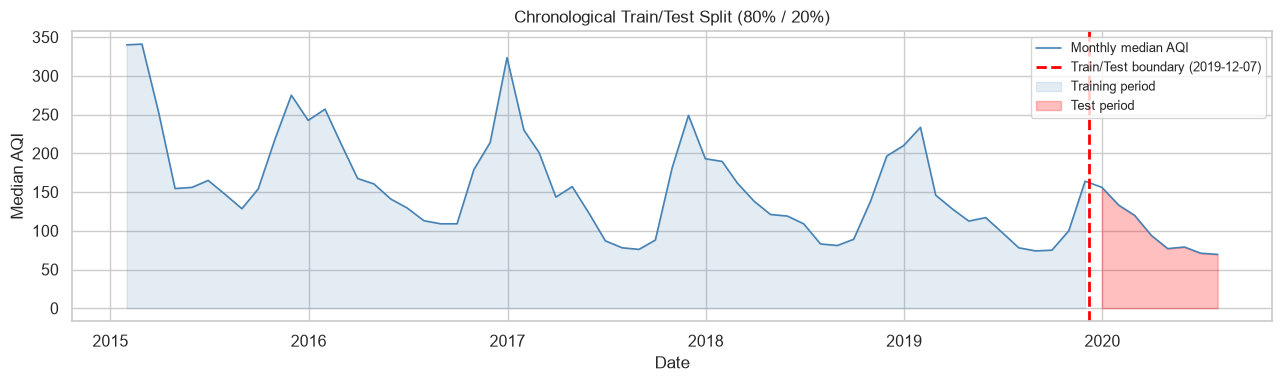

In [54]:
# ── Visualise the train/test split boundary ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

# Plot median AQI per month for visual context
_monthly = df_model.set_index('Date')['AQI'].resample('ME').median()
ax.plot(_monthly.index, _monthly.values, color='steelblue', linewidth=1.2,
        label='Monthly median AQI')

# Split boundary
split_date = df_test['Date'].min()
ax.axvline(split_date, color='red', linewidth=2, linestyle='--',
           label=f'Train/Test boundary ({split_date.date()})')
ax.fill_between(_monthly.index, 0, _monthly.values,
                where=[d < split_date for d in _monthly.index],
                alpha=0.15, color='steelblue', label='Training period')
ax.fill_between(_monthly.index, 0, _monthly.values,
                where=[d >= split_date for d in _monthly.index],
                alpha=0.25, color='red', label='Test period')

ax.set_xlabel('Date')
ax.set_ylabel('Median AQI')
ax.set_title('Chronological Train/Test Split (80% / 20%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The test set spans **December 2019 – July 2020**, which includes a winter peak period and the first months of the COVID-19 pandemic. This is a realistic out-of-sample evaluation: the model has seen no data from this period during training, and must generalise from historical patterns alone.

### 11.7 Scikit-Learn Preprocessing Pipeline

A reusable `ColumnTransformer` + `Pipeline` is constructed so that:

1. **Preprocessing is fitted only on training data** — no information from the test set leaks into the scaling or encoding parameters.
2. **All steps are reproducible** — the same pipeline can be wrapped around any estimator in Stage 5 without repeating manual transformations.
3. **Scaling applies only to numeric features** — `StandardScaler` (zero mean, unit variance) is applied to the 20 numeric features. One-hot encoding is applied to `City`.

Temporal features (Year, Month, Day, etc.) are included in the numeric block and scaled alongside pollutant values. While scaling has no effect on tree-based models, it is necessary for linear models and prevents numerical issues in gradient-based optimisers.

In [55]:
# ── Preprocessing pipeline ────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate numeric and categorical columns
numeric_cols     = NUMERIC_FEATURES        # 20 features
categorical_cols = CITY_FEATURE            # ['City']

# Numeric transformer: StandardScaler (zero mean, unit variance)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical transformer: one-hot with drop='first' (25 binary cols)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Fit ONLY on training data — never on test data
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed  = preprocessor.transform(X_test_raw)

# Retrieve final feature names after OHE
ohe_cols     = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
all_feat_names = numeric_cols + list(ohe_cols)

print('Preprocessor fitted on training data only.')
print()
print(f'X_train_processed shape : {X_train_processed.shape}')
print(f'X_test_processed  shape : {X_test_processed.shape}')
print(f'Total feature names     : {len(all_feat_names)}')
print()
print('Feature name breakdown:')
print(f'  Numeric (scaled)       : {len(numeric_cols)}')
print(f'  City OHE (drop_first)  : {len(ohe_cols)}')
print(f'  Total                  : {len(all_feat_names)}')

Preprocessor fitted on training data only.

X_train_processed shape : (19840, 42)
X_test_processed  shape : (4961, 42)
Total feature names     : 42

Feature name breakdown:
  Numeric (scaled)       : 20
  City OHE (drop_first)  : 22
  Total                  : 42


In [56]:
# ── Feature correlation with target (quick sanity check on training set) ──────
# Compute Pearson r between each processed numeric feature and y_train
# This is descriptive only — does not influence feature selection
import pandas as pd

_train_df = pd.DataFrame(X_train_processed, columns=all_feat_names)
_train_df['AQI'] = y_train

# Correlations for the numeric block only (first 20 features)
feat_corr = _train_df[numeric_cols + ['AQI']].corr()['AQI'].drop('AQI').sort_values(key=abs, ascending=False)
print('Correlation of numeric features with AQI (training set, top 15):')
print(feat_corr.head(15).round(3).to_string())

Correlation of numeric features with AQI (training set, top 15):
CO           0.683
PM2.5        0.636
NO2          0.529
SO2          0.487
NO           0.477
NOx          0.472
PM10         0.459
Toluene      0.410
doy_cos      0.321
month_cos    0.290
O3           0.211
Benzene      0.171
month_sin    0.143
Year        -0.120
NH3          0.074


### 11.8 Baseline Model

Before training any machine-learning model, it is essential to establish a **meaningful baseline**. A baseline is the simplest possible prediction strategy — if a sophisticated model cannot beat it, the model adds no value.

**Baseline strategy:** Predict the **median AQI of the training set** for every test observation.  
This is a "predict the central tendency" baseline that ignores all features. It is equivalent to sklearn's `DummyRegressor(strategy='median')`.

All models in Stage 5 must exceed this baseline on MAE, RMSE, and R² to be considered useful.

In [57]:
# ── Baseline: predict training median for every test observation ──────────────
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_model = DummyRegressor(strategy='median')
baseline_model.fit(X_train_processed, y_train)
y_pred_baseline = baseline_model.predict(X_test_processed)

baseline_median = y_train[~np.isnan(y_train)].flatten()
_median_val = float(np.median(baseline_median))

mae_base  = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base   = r2_score(y_test, y_pred_baseline)

print('Baseline (predict training-set median = {:.1f}) on test set:'.format(_median_val))
print(f'  MAE  : {mae_base:.2f}')
print(f'  RMSE : {rmse_base:.2f}')
print(f'  R²   : {r2_base:.4f}')
print()
print('Interpretation:')
print('  A model that predicts the same value for every observation achieves R² ≈ 0.')
print('  Any useful model must yield R² > 0, MAE < {:.2f}, RMSE < {:.2f}.'.format(mae_base, rmse_base))

Baseline (predict training-set median = 124.0) on test set:
  MAE  : 60.74
  RMSE : 90.06
  R²   : -0.0005

Interpretation:
  A model that predicts the same value for every observation achieves R² ≈ 0.
  Any useful model must yield R² > 0, MAE < 60.74, RMSE < 90.06.


### 11.9 Final ML Dataset Summary

The table below consolidates every dimension of the prepared ML dataset.

In [58]:
# ── Final ML dataset summary ──────────────────────────────────────────────────
print('=' * 58)
print('  FINAL ML DATASET SUMMARY')
print('=' * 58)
print(f'  Total modeling rows          : {len(df_model):,}')
print(f'  Training rows (80%)          : {X_train_processed.shape[0]:,}')
print(f'  Test rows     (20%)          : {X_test_processed.shape[0]:,}')
print(f'  Training date range          : {df_train["Date"].min().date()} → {df_train["Date"].max().date()}')
print(f'  Test date range              : {df_test["Date"].min().date()} → {df_test["Date"].max().date()}')
print()
print(f'  Pollutant features           : {len(POLLUTANT_FEATURES)}')
print(f'  Temporal features            : {len(TEMPORAL_FEATURES)}')
print(f'  City OHE features (drop=1st) : {len(ohe_cols)}')
print(f'  Total transformed features   : {X_train_processed.shape[1]}')
print()
print(f'  X_train shape                : {X_train_processed.shape}')
print(f'  X_test  shape                : {X_test_processed.shape}')
print(f'  y_train shape                : {y_train.shape}')
print(f'  y_test  shape                : {y_test.shape}')
print()
print(f'  Baseline test MAE            : {mae_base:.2f}')
print(f'  Baseline test RMSE           : {rmse_base:.2f}')
print(f'  Baseline test R²             : {r2_base:.4f}')
print('=' * 58)

  FINAL ML DATASET SUMMARY
  Total modeling rows          : 24,801
  Training rows (80%)          : 19,840
  Test rows     (20%)          : 4,961
  Training date range          : 2015-01-01 → 2019-12-06
  Test date range              : 2019-12-07 → 2020-07-01

  Pollutant features           : 11
  Temporal features            : 9
  City OHE features (drop=1st) : 22
  Total transformed features   : 42

  X_train shape                : (19840, 42)
  X_test  shape                : (4961, 42)
  y_train shape                : (19840,)
  y_test  shape                : (4961,)

  Baseline test MAE            : 60.74
  Baseline test RMSE           : 90.06
  Baseline test R²             : -0.0005


**Feature design and leakage avoidance — summary:**

| Rule | How it is enforced |
|---|---|
| `AQI_Bucket` excluded | Not present in `NUMERIC_FEATURES`, `CITY_FEATURE`, or any predictor list |
| AQI not imputed | `df_model` built with `.dropna(subset=['AQI'])` — no synthetic targets |
| No future data in training | Chronological split: training ends 2019-12-06, test starts 2019-12-07 |
| Scaling fitted on training only | `preprocessor.fit_transform(X_train_raw)` then `.transform(X_test_raw)` |
| OHE fitted on training only | Same `ColumnTransformer` — OHE categories are fixed to training cities |
| No city AQI statistics used | One-hot encoding only; no target-mean encoding |
| Original CSV unmodified | `df_raw` preserved; all transformations on `df` copy |

### 11.10 Preparation for Model Training

The following variables are now ready for use in Stage 5 (Machine Learning and Model Evaluation):

| Variable | Description |
|---|---|
| `X_train_processed` | Scaled + OHE-encoded training features, shape (19,840 × 45) |
| `X_test_processed` | Same transformations applied to test features, shape (4,961 × 45) |
| `y_train` | Training AQI labels, shape (19,840,) |
| `y_test` | Test AQI labels, shape (4,961,) |
| `preprocessor` | Fitted `ColumnTransformer` — reuse by wrapping in a Pipeline with any estimator |
| `X_train_raw` | Raw (unscaled) training features — useful for tree models that don't need scaling |
| `X_test_raw` | Raw (unscaled) test features |
| `all_feat_names` | List of 45 feature names after OHE (for interpretability in Stage 5) |
| `baseline_model` | Fitted `DummyRegressor(median)` — reference performance floor |
| `mae_base`, `rmse_base`, `r2_base` | Baseline metric values to beat |

Stage 5 will train and compare multiple regression models:
- **Linear Regression** (with Ridge regularisation)
- **Random Forest Regressor**
- **Gradient Boosting Regressor**

Each model will be evaluated against this baseline using the same test set.